# A meta-analysis of datasets at the interface of the plant circadian

clock and the responses to temperature

Allan James [](https://orcid.org/0000-0003-4472-7095) (Independent researcher)  
August 2, 2026

Previously published Chromatin immunoprecipitation (ChIP) genome-wide binding targets for eight Arabidopsis circadian clock proteins were characterised here for their prevalence in clusters of co-expressed genes from the Calixto *et al.*\[@RN429\] temperature and time series dataset of 7,302 differentially expressed (DE) genes. Categorisation of the DE gene clusters for their rhythmicity signals, particularly for amplitude changes during cooling transition, and the establishment clock-target enrichment for the clusters revealed three modules: a morning modest gain of amplitude group, a mid-afternoon high gain of amplitude group, and a mid-afternoon/evening high loss of amplitude group. Network analyses illustrated the relationships between clock components and their DE gene targets and showed that BBX29 (mid-afternoon high gain of amplitude group) and PIF4 (mid-afternoon/evening high loss of amplitude group) were targets of all the eight clock components. Detection of densely connected vertices (‘community detection’) within the clock targeted cold network point to the mid-afternoon high gain of amplitude group as a particular nexus between the clock and plants immediate and rapid response to cooling. The meta-analysis approach used here showcases the utility of ‘dry lab’ approaches to developing testable hypotheses in plant biology research.

## Introduction

How plants respond to temperature continues to be a challenging question in plant biology, not least because responses are thought to involve multiple signal pathways\[@RN859; @RN861; @RN862; @RN215; @RN113; @RN700; @RN865\], can be fast acting, with rapid metabolic and gene expression changes observable within 2-20 minutes\[@RN858; @RN601; @RN860; @RN429\], or they can be integrated over the longer-term (days or weeks), leading to developmental changes such as the promotion of flowering via vernalisation, or the breaking of bud dormancy\[@RN701; @RN217; @RN576; @RN864\].

Time – and it’s measurement by the endogenous circadian clock – is therefore a crucial dimension to plants responses to temperature. Mathematical modelling and experimental validation of vernalisation gene expression dynamics for plants grown under both controlled and natural field conditions have established that temperature sensing is likely distributed across thermo-responsive regulatory networks operating over at least three distinct timescales (hour, day and month), with the day component particularly sensitivity to night-time temperature during the daily 24-hr diurnal cycle\[@RN448; @RN447\].

At least one of the ways in which the clock is thought to influence plants physiological responses to low temperature is through time-of-day gating of downstream gene expression cascades. Within minutes of exposing plants to low temperature, induction of the *C-repeat-binding factor (CBF)1,-2* and *-3* transcriptional activator genes (also known as *dehydration-responsive element-binding factor (DREB)1b, -1c* and *-1a*, respectively) are evident leading to waves of changes in transcriptome composition\[@RN249; @RN698; @RN699\]. However, the rapid induction of the CBFs is dependent on the time-of-day that the plants are exposed to low temperature with expression more pronounced around subjective dawn compared to subjective dusk under constant light conditions\[@RN250\]. Expression of the circadian clock network, at least at the post-transcriptional level, is not immutable with temperature-associated alternative splicing (AS), including the rapid and sensitive switching between functional and non-functional transcript isoforms\[@RN860; @RN427\], thought to be a mechanism involved in the operation and regulation of the clock\[@RN16; @RN15\].

The core circadian oscillator in Arabidopsis is made up of around twenty or so components and features multiple interlocking feedback loops of gene expression, modulated by post-translational control at several levels\[@RN91; @RN866; @RN867; @RN868; @RN869\], with additional inputs from factors, such as light and metabolism\[@RN868; @RN461; @RN871\]. The first loop to be discovered comprises the morning-expressed MYB transcription factors CIRCADIAN CLOCK ASSOCIATED 1 (CCA1) and LATE ELONGATED HYPOCOTYL (LHY) and the evening-phased transcriptional repressor PSEUDO-RESPONSE REGULATOR 1 (PRR1, also known as TIMING OF CAB EXPRESSION 1, TOC1). LHY and CCA1 belong to the REVEILLE (RVE) family of proteins, all of which contain a single DNA-binding Myb-like domain. Other Myb-like family members are the RVEs 1 to 8. The core oscillator also features the day-phased transcriptional repressors PRR9, PRR7 and PRR5, the evening-phased components EARLY FLOWERING 3 (ELF3), ELF4 and LUX ARRHYTHMO (LUX) which interact to form a transcriptional repressor named the evening complex (EC)\[@RN870\].

Here, I took a data-led approach to characterise the interface between timing and plants endogenous responses to temperature. Our starting points were datasets from 1) genome wide ChIP-seq studies establishing circadian clock binding sites and 2) an RNA-seq study identifying patterns of differential expression in plants responding to cooling. The former datasets contained circadian clock gene targets for CCA1\[@RN445; @RN486\], LHY\[@RN487\], TOC1\[@RN679\], PRR5\[@RN681\], PRR7\[@RN680\] and the EC components, ELF3, ELF4 and LUX\[@RN371\], while the latter comprised 7.3k differentially expressed (DE) genes from a diurnal RNA-seq time-course experiment for plants grown at 20°C and then subjected to cooling to 4°C\[@RN429\].

I established clusters of DE genes that were particularly enriched for clock targets and by characterising the rhythmic properties of the averaged diurnal expression profiles across time and temperature as well as the extent to which DE genes were targets of multiple clock components, I constructed weighted bipartite networks that illustrated the relationships between clock components and their DE gene targets. Of note were DE genes that were targets of multiple clock components, including B-box containing protein29 (BBX29; AT5G54470) and PHYTOCHROME-INTERACTING FACTOR 4 (PIF4; AT2G43010), both of which were found in each of the 8 clock component ChIP datasets examined. Using the meta-analysis approach, I defined groups of clusters that DE genes belonged to according to their clock enrichment and the change in amplitude during the first day of cooling and I found that, for example, BBX29 belonged to a ‘mid-afternoon high gain of amplitude module’ and PIF4 to a ‘mid-afternoon/evening high loss of amplitude module’. The community structure of the networks pointed to the high connectivity of the ‘mid-afternoon high gain of amplitude module’ suggesting that this clock-DE gene sub-network represented an important nexus in the interface of the circadian clock and the response of plants to temperature.

## Results

In [ ]:
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test

ggbreak v0.1.2

If you use ggbreak in published research, please cite the following
paper:

S Xu, M Chen, T Feng, L Zhan, L Zhou, G Yu. Use ggbreak to effectively
utilize plotting space to deal with large datasets and outliers.
Frontiers in Genetics. 2021, 12:774846. doi: 10.3389/fgene.2021.774846

In [ ]:
# CLUSTER GROUP PROFILES - WebPlotDigitizer----
# DE profiles----
# gather and join together all the WebPlotDigitizer files for each cluster group
# WebPlotDigitizer https://apps.automeris.io/wpd/
clusters_aggregated_DE <- list.files(path = './01_tidy_data/cluster_image_analysis_aggregate_DE', 
                                  pattern = '*.csv', full.names = TRUE) %>% 
  lapply(read_csv, show_col_types = FALSE) %>% 
  purrr::reduce(full_join, by = 'id') %>% 
  janitor::remove_empty(which = 'cols') %>% 
  relocate(c(cluster_1, cluster_2, cluster_3, cluster_4, cluster_5, cluster_6, cluster_7, 
             cluster_8, cluster_9), .before = cluster_10) 

# split by individual days
clusters_aggregated_DE_day1 <- clusters_aggregated_DE[row.names(clusters_aggregated_DE) %in% 1:17, ]
clusters_aggregated_DE_day2 <- clusters_aggregated_DE[row.names(clusters_aggregated_DE) %in% 17:33, ]
clusters_aggregated_DE_day5 <- clusters_aggregated_DE[row.names(clusters_aggregated_DE) %in% 34:50, ]

# transpose so that columns are sample numbers (s1 to s9 in half steps) and rows are cluster groups, and rename columns
clusters_aggregated_DE_day1_df <- data.frame(t(clusters_aggregated_DE_day1[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 1, to = 9, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:12)) %>% 
  relocate(clusters) 

clusters_aggregated_DE_day2_df <- data.frame(t(clusters_aggregated_DE_day2[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 9, to = 17, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:12)) %>% 
  relocate(clusters) 

clusters_aggregated_DE_day5_df <- data.frame(t(clusters_aggregated_DE_day5[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 18, to = 26, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:12)) %>% 
  relocate(clusters) 

#Selected clusters plotted ----

clusters_aggregated_DE_pivot_longer <- clusters_aggregated_DE %>% 
  pivot_longer(cols = starts_with ('cluster'),
               names_to = "cluster", 
               values_to = "z_score") %>%
  mutate(id = case_when(id == 1 ~ 0,
                        id == 1.5 ~ 1.5,
                        id == 2 ~ 3,
                        id == 2.5 ~ 4.5,
                        id == 3 ~ 6,
                        id == 3.5 ~ 7.5,
                        id == 4 ~ 9,
                        id == 4.5 ~ 10.5,
                        id == 5 ~ 12,
                        id == 5.5 ~ 13.5,
                        id == 6 ~ 15,
                        id == 6.5 ~ 16.5,
                        id == 7 ~ 18,
                        id == 7.5 ~ 19.5,
                        id == 8 ~ 21,
                        id == 8.5 ~ 22.5,
                        id == 9 ~ 24,
                        id == 9.5 ~ 25.5,
                        id == 10 ~ 27,
                        id == 10.5 ~ 28.5,
                        id == 11 ~ 30,
                        id == 11.5 ~ 31.5,
                        id == 12 ~ 33,
                        id == 12.5 ~ 34.5,
                        id == 13 ~ 36,
                        id == 13.5 ~ 37.5,
                        id == 14 ~ 39,
                        id == 14.5 ~ 40.5,
                        id == 15 ~ 42,
                        id == 15.5 ~ 43.5,
                        id == 16 ~ 45,
                        id == 16.5 ~ 46.5,
                        id == 17 ~ 48,
                        id == 18 ~ 96,
                        id == 18.5 ~ 97.5,
                        id == 19 ~ 99,
                        id == 19.5 ~ 100.5,
                        id == 20 ~ 102,
                        id == 20.5 ~ 103.5,
                        id == 21 ~ 105,
                        id == 21.5 ~ 106.5,
                        id == 22 ~ 108,
                        id == 22.5 ~ 109.5,
                        id == 23 ~ 111,
                        id == 23.5 ~ 112.5,
                        id == 24 ~ 114,
                        id == 24.5 ~ 115.5,
                        id == 25 ~ 117,
                        id == 25.5 ~ 118.5,
                        id == 26 ~ 120),
         days = case_when(id <= 48 ~ 'Day 1 - Day 2',
                          TRUE ~ 'Day 5'),
         cluster = case_when(cluster == 'cluster_1' ~ 'cluster 1',
                             cluster == 'cluster_2' ~ 'cluster 2',
                             cluster == 'cluster_3' ~ 'cluster 3',
                             cluster == 'cluster_4' ~ 'cluster 4',
                             cluster == 'cluster_5' ~ 'cluster 5',
                             cluster == 'cluster_6' ~ 'cluster 6',
                             cluster == 'cluster_7' ~ 'cluster 7',
                             cluster == 'cluster_8' ~ 'cluster 8',
                             cluster == 'cluster_9' ~ 'cluster 9',
                             cluster == 'cluster_10' ~ 'cluster 10',
                             cluster == 'cluster_11' ~ 'cluster 11',
                             cluster == 'cluster_12' ~ 'cluster 12',
                             TRUE ~ NA))

clusters_aggregated_DE_pivot_longer <- clusters_aggregated_DE_pivot_longer %>% 
  mutate(days = factor(days, levels = c('Day 1 - Day 2', 'Day 5')))

# DTU profiles----
# gather and join together all the WebPlotDigitizer files for each cluster group
# WebPlotDigitizer https://apps.automeris.io/wpd/
clusters_aggregated_DTU <- list.files(path = './01_tidy_data/cluster_image_analysis_aggregate_DTU', 
                                  pattern = '*.csv', full.names = TRUE) %>% 
  lapply(read_csv, show_col_types = FALSE) %>% 
  purrr::reduce(full_join, by = 'id') %>% 
  janitor::remove_empty(which = 'cols') %>% 
  relocate(c(cluster_1, cluster_2, cluster_3, cluster_4, cluster_5, cluster_6, cluster_7, 
             cluster_8, cluster_9), .before = cluster_10) 

# split by individual days
clusters_aggregated_DTU_day1 <- clusters_aggregated_DTU[row.names(clusters_aggregated_DTU) %in% 1:17, ]
clusters_aggregated_DTU_day2 <- clusters_aggregated_DTU[row.names(clusters_aggregated_DTU) %in% 17:33, ]
clusters_aggregated_DTU_day5 <- clusters_aggregated_DTU[row.names(clusters_aggregated_DTU) %in% 34:50, ]

# transpose so that columns are sample numbers (s1 to s9 in half steps) and rows are cluster groups, and rename columns
clusters_aggregated_DTU_day1_df <- data.frame(t(clusters_aggregated_DTU_day1[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 1, to = 9, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:10)) %>% 
  relocate(clusters) 

clusters_aggregated_DTU_day2_df <- data.frame(t(clusters_aggregated_DTU_day2[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 9, to = 17, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:10)) %>% 
  relocate(clusters) 

clusters_aggregated_DTU_day5_df <- data.frame(t(clusters_aggregated_DTU_day5[, -1])) %>% 
  rename_with(~ paste0("s", seq(from = 18, to = 26, by = 0.5))) %>% 
  mutate(clusters = paste0("cluster_", 1:10)) %>% 
  relocate(clusters) 

# Selected clusters plotted ----

clusters_aggregated_DTU_pivot_longer <- clusters_aggregated_DTU %>% 
  pivot_longer(cols = starts_with ('cluster'),
               names_to = "cluster", 
               values_to = "z_score") %>%
  mutate(id = case_when(id == 1 ~ 0,
                        id == 1.5 ~ 1.5,
                        id == 2 ~ 3,
                        id == 2.5 ~ 4.5,
                        id == 3 ~ 6,
                        id == 3.5 ~ 7.5,
                        id == 4 ~ 9,
                        id == 4.5 ~ 10.5,
                        id == 5 ~ 12,
                        id == 5.5 ~ 13.5,
                        id == 6 ~ 15,
                        id == 6.5 ~ 16.5,
                        id == 7 ~ 18,
                        id == 7.5 ~ 19.5,
                        id == 8 ~ 21,
                        id == 8.5 ~ 22.5,
                        id == 9 ~ 24,
                        id == 9.5 ~ 25.5,
                        id == 10 ~ 27,
                        id == 10.5 ~ 28.5,
                        id == 11 ~ 30,
                        id == 11.5 ~ 31.5,
                        id == 12 ~ 33,
                        id == 12.5 ~ 34.5,
                        id == 13 ~ 36,
                        id == 13.5 ~ 37.5,
                        id == 14 ~ 39,
                        id == 14.5 ~ 40.5,
                        id == 15 ~ 42,
                        id == 15.5 ~ 43.5,
                        id == 16 ~ 45,
                        id == 16.5 ~ 46.5,
                        id == 17 ~ 48,
                        id == 18 ~ 96,
                        id == 18.5 ~ 97.5,
                        id == 19 ~ 99,
                        id == 19.5 ~ 100.5,
                        id == 20 ~ 102,
                        id == 20.5 ~ 103.5,
                        id == 21 ~ 105,
                        id == 21.5 ~ 106.5,
                        id == 22 ~ 108,
                        id == 22.5 ~ 109.5,
                        id == 23 ~ 111,
                        id == 23.5 ~ 112.5,
                        id == 24 ~ 114,
                        id == 24.5 ~ 115.5,
                        id == 25 ~ 117,
                        id == 25.5 ~ 118.5,
                        id == 26 ~ 120),
         days = case_when(id <= 48 ~ 'Day 1 - Day 2',
                          TRUE ~ 'Day 5'),
         cluster = case_when(cluster == 'cluster_1' ~ 'cluster 1',
                             cluster == 'cluster_2' ~ 'cluster 2',
                             cluster == 'cluster_3' ~ 'cluster 3',
                             cluster == 'cluster_4' ~ 'cluster 4',
                             cluster == 'cluster_5' ~ 'cluster 5',
                             cluster == 'cluster_6' ~ 'cluster 6',
                             cluster == 'cluster_7' ~ 'cluster 7',
                             cluster == 'cluster_8' ~ 'cluster 8',
                             cluster == 'cluster_9' ~ 'cluster 9',
                             cluster == 'cluster_10' ~ 'cluster 10',
                             TRUE ~ NA))

clusters_aggregated_DTU_pivot_longer <- clusters_aggregated_DTU_pivot_longer %>% 
  mutate(days = factor(days, levels = c('Day 1 - Day 2', 'Day 5')))

# read the gene and transcript clusters
# The DE network (Suppl dataset 7A) is 6810 genes over 12 clusters (clusters 1-12)
# The DTU network (Suppl dataset 7B) is 3972 transcripts over 10 clusters (clusters 1-10)

calixto_S7A <- read_csv("./00_raw_data/Calixto_suppl_dataset_7A_DE.csv") %>%
  select(2:13) %>% 
  pivot_longer(cols = starts_with ('cluster'),
               names_to = "cluster", 
               values_to = "gene_ID",
               values_drop_na = TRUE) %>% 
  filter(grepl('AT', gene_ID)) %>%
  mutate(cluster = str_sub(cluster, 9, -1))

Rows: 1141 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): Cluster 0, Cluster 1, Cluster 2, Cluster 3, Cluster 4, Cluster 5, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 1116 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): Cluster 0, Cluster 1, Cluster 2, Cluster 3, Cluster 4, Cluster 5, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="100.0%" data-layout-align="left">
<div class="cell" data-layout-align="center">
<div class="cell-output-display">
<div>
<p><figure class=''></p>
<div>
<pre class="mermaid mermaid-js">
flowchart LR
    A[&lt;center&gt;DE/DTU clusters &lt;br&gt; Calixto &lt;i&gt;et al.&lt;/i&gt; 2018&lt;/center&gt;] --&gt; B(3 days d1, d2, d5)
    B --&gt; |3h time points| C{WebPlotDigitizer}
    C --&gt; |1.5h time-points| D[DE]
    C --&gt; |1.5h time-points| E[DTU]
    D --&gt; F{MetaCycle}
    E --&gt; F
</pre>
</div>
<p></figure></p>
</div>
</div>
</div>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="100.0%" data-layout-align="left">
<div class="cell" data-layout-align="center">
<div class="cell-output-display">
<div>
<p><figure class=''></p>
<div>
<pre class="mermaid mermaid-js">flowchart LR
  A{MetaCycle} --&gt; B(DE rhythmic signals)
  A --&gt; C(DTU rhythmic signals)
  B --&gt; D(&lt;center&gt;cluster classification: &lt;br&gt; d1 vs d2/d1 vs d5 &lt;br&gt; gain/loss of &lt;br&gt; rhythmic signals&lt;/center&gt;)
    C --&gt; D
    D --&gt; E(enrichment for clock ChIP targets)
    E --&gt; F(bipartite clock-linked DE/DTU network)
</pre>
</div>
<p></figure></p>
</div>
</div>
</div>
</div></td>
</tr>
</tbody>
</table>

This is a methods caption.

See @fig-method-diagram for the complete method. Specifically, @fig-method-a highlights the first initial phase, while @fig-method-b details the second phase.

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<p>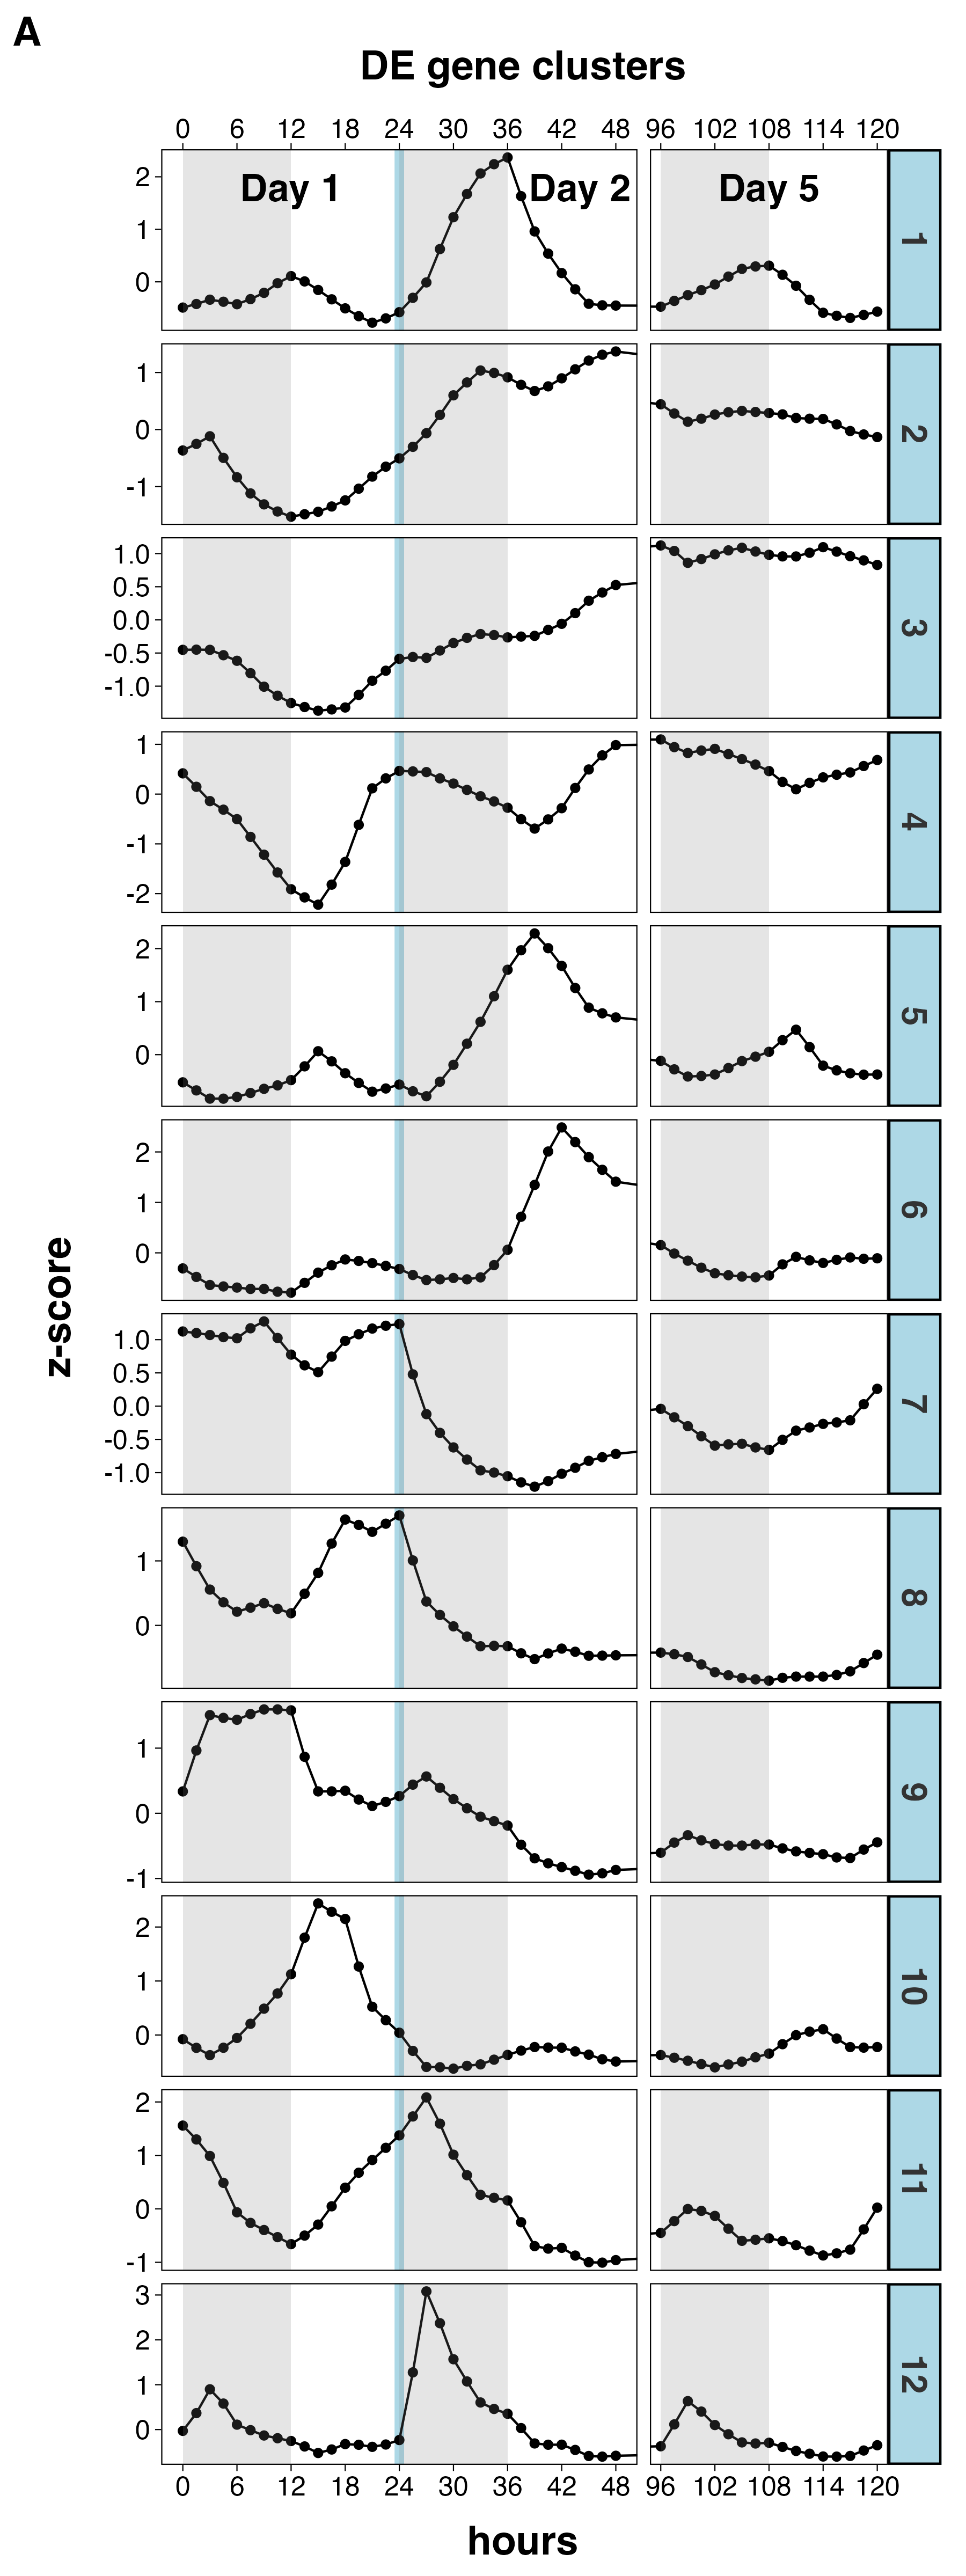</p>
</div></td>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<p>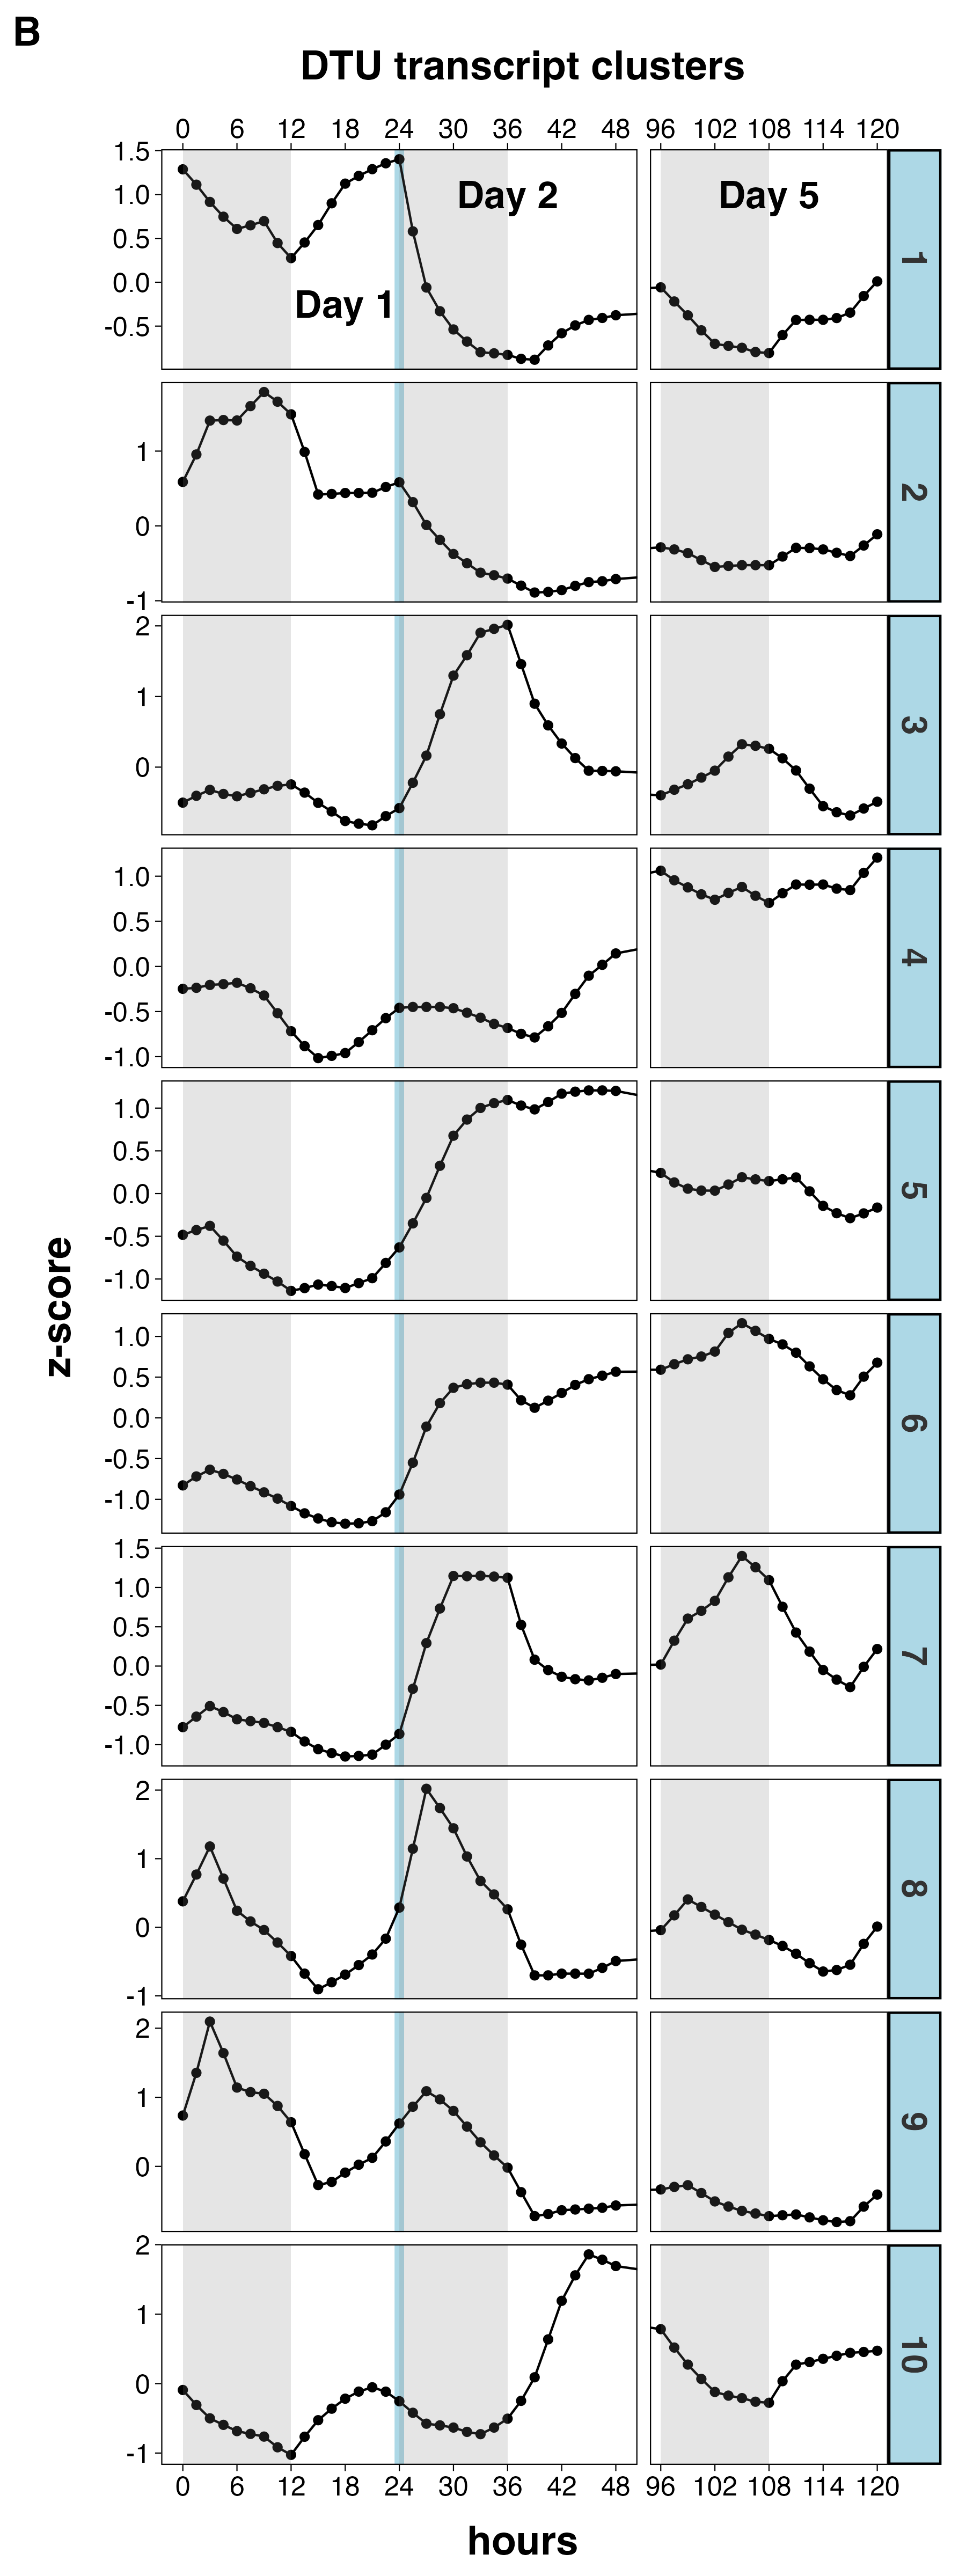</p>
</div></td>
</tr>
</tbody>
</table>

Plots of the averaged z-score cluster profiles for DE genes and DTU transcripts.

See @fig-zscore-clusters for the complete analysis. Specifically, @fig-clusters-a highlights the initial phase, while @fig-clusters-b details the outcome.

In [ ]:
#| message: false
#| warning: false

# CLOCK ChIP DATASETS----

# LHY

# LHY dataset
# read in the Adams LHY paper dataset and skip first 2 lines
# The LHY paper is Adams et al. (2018) New Phytologist 220(3); 897
# supplemental data set (Table S2) 
adams <- read_csv("./00_raw_data/nph15415-sup-0002-tables2.csv",skip=2) %>% 
  dplyr::select(gene_ID = 1) %>%
  filter(!is.na(gene_ID)) %>%
  distinct(gene_ID) %>%
  mutate(clock = 'LHY') 

Rows: 727 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): gene ID, gene name, Phase in LL(LL23), fiunctional description

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

e.g.:
  dat <- vroom(...)
  problems(dat)

Rows: 1433 Columns: 32
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): PeakID, Strand, Annotation, Nearest PromoterID, Nearest Unigene, N...
dbl (23): Chr, Start, End, Peak Score, Focus Ratio/Region Size, Distance to ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 449 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): Peak/ Nearest gene, Peak name, Gene strand orientation, Nearest Ge...
dbl (12): Chromosome name, Start position of peak (PGM), End position of pea...
lgl  (1): CCA1-bound, by Nagel et al.,, Figure S2. True (T, if Nagel et al.,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

New names:
Rows: 65277 Columns: 21
── Column specification
──────────────────────────────────────────────────────── Delimiter: "," chr
(10): ChIP-Seq peak ID, Gene ID (At#)...3, Strand, Relative Position, Ge... dbl
(11): Chromosome, Gene 5' end, Gene 3' end, Peak 5' end, Peak 3' end, Pe...
ℹ Use `spec()` to retrieve the full column specification for this data. ℹ
Specify the column types or set `show_col_types = FALSE` to quiet this message.
• `Gene ID (At#)` -> `Gene ID (At#)...3`
• `Gene ID (At#)` -> `Gene ID (At#)...14`

Rows: 64 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): Mapping, Region, GeneID, Gene name, direction, probe ID of GeneChi...
dbl  (5): distance, WT-ZT12-ave, 5VP-ZT12-ave, fc. 5VP-WT, FDR, WT<5VP

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 113 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (23): Rank (ExpI), EF (ExpI), Rank (ExpII), EF (ExpII), Binding Site (Ex...
dbl  (2): TSS, TST

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 827 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Locus Identifier, Gene Model Name, Gene Model Description, Gene Mod...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 214 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Locus Identifier, Gene Model Name, Gene Model Description, Gene Mod...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 45 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Locus Identifier, Gene Model Name, Gene Model Description, Gene Mod...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.

In [ ]:
summarise_table_final |>
  gt() |>
  tab_header(
    title = md("**Clock ChIP targets and their overlap with DE and DTU cluster constituents**"),
    subtitle = " ") |>
  tab_spanner(
    label = "Common targets",
    columns = c('DE_clusters', 'DTU_clusters')
  ) |>
  tab_spanner(
    label = "ChIP datasets",
    columns = c('Epitope', 'cis_targets')
  ) |>
  tab_footnote(
    footnote = md("CIRCADIAN CLOCK ASSOCIATED-1, Table S1 Nagel *et al.* (2015)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 1)
  ) |>
  tab_footnote(
    footnote = md("CIRCADIAN CLOCK ASSOCIATED-1, Table S1C Kamioka *et al.* (2016)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 2)
  ) |>
  tab_footnote(
    footnote = md("LATE ELONGATED HYPOCOTYL, Table S2 Adams *et al.* (2018)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 3)
  ) |>
  tab_footnote(
    footnote = md("TIMING OF CAB2 EXPRESSION1, Table S1 Huang *et al.* (2012)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 4)
  ) |>
  tab_footnote(
    footnote = md("PSEUDO-RESPONSE REGULATOR5, Table S3 Nakamichi *et al.* (2012)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 5)
  ) |>
  tab_footnote(
    footnote = md("PSEUDO-RESPONSE REGULATOR7, Dataset S1 Liu *et al.* (2013)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 6)
  ) |>
  tab_footnote(
    footnote = md("LUX ARRYTHMO, LUX_17 tab of Table S6 Ezer *et al.* (2017)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 7)
  ) |>
  tab_footnote(
    footnote = md("EARLY FLOWERING3, ELF3_22 tab of Table S6 Ezer *et al.* (2017)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 8)
  ) |>
  tab_footnote(
    footnote = md("EARLY FLOWERING4, ELF4_22 tab of Table S6 Ezer *et al.* (2013)"),
    locations = cells_body(columns = c('transfactor', 'cis_targets'), rows = 9)
  ) |>
  fmt_number(
    columns = 'cis_targets',
    sep_mark = ',',
    decimals = 0
  ) |>
  cols_align(
    align = "center",
    columns = c('cis_targets', 'DE_clusters', 'DTU_clusters')
  ) |>
  cols_label(transfactor = md("*trans* factor"),
             cis_targets = md("*cis* targets"),
             DE_clusters = "DE clusters",
             DTU_clusters = "DTU clusters",
             percent_DE = "% DE",
             percent_DTU = "% DTU") %>% 
  gt_plt_bar_pct(column = percent_DE, scaled = TRUE,
                 labels = TRUE,
                 fill = "#ef8a62", background = "#feb797") %>%
  gt_plt_bar_pct(column = percent_DTU, scaled = TRUE,
                 labels = TRUE,
                 fill = "#999999", background = "#d6d6d6") |>
  cols_align(
    align = "center",
    columns = c('percent_DE', 'percent_DTU')) |>
  tab_spanner(
    label = "Overlap",
    columns = c('percent_DE', 'percent_DTU'))

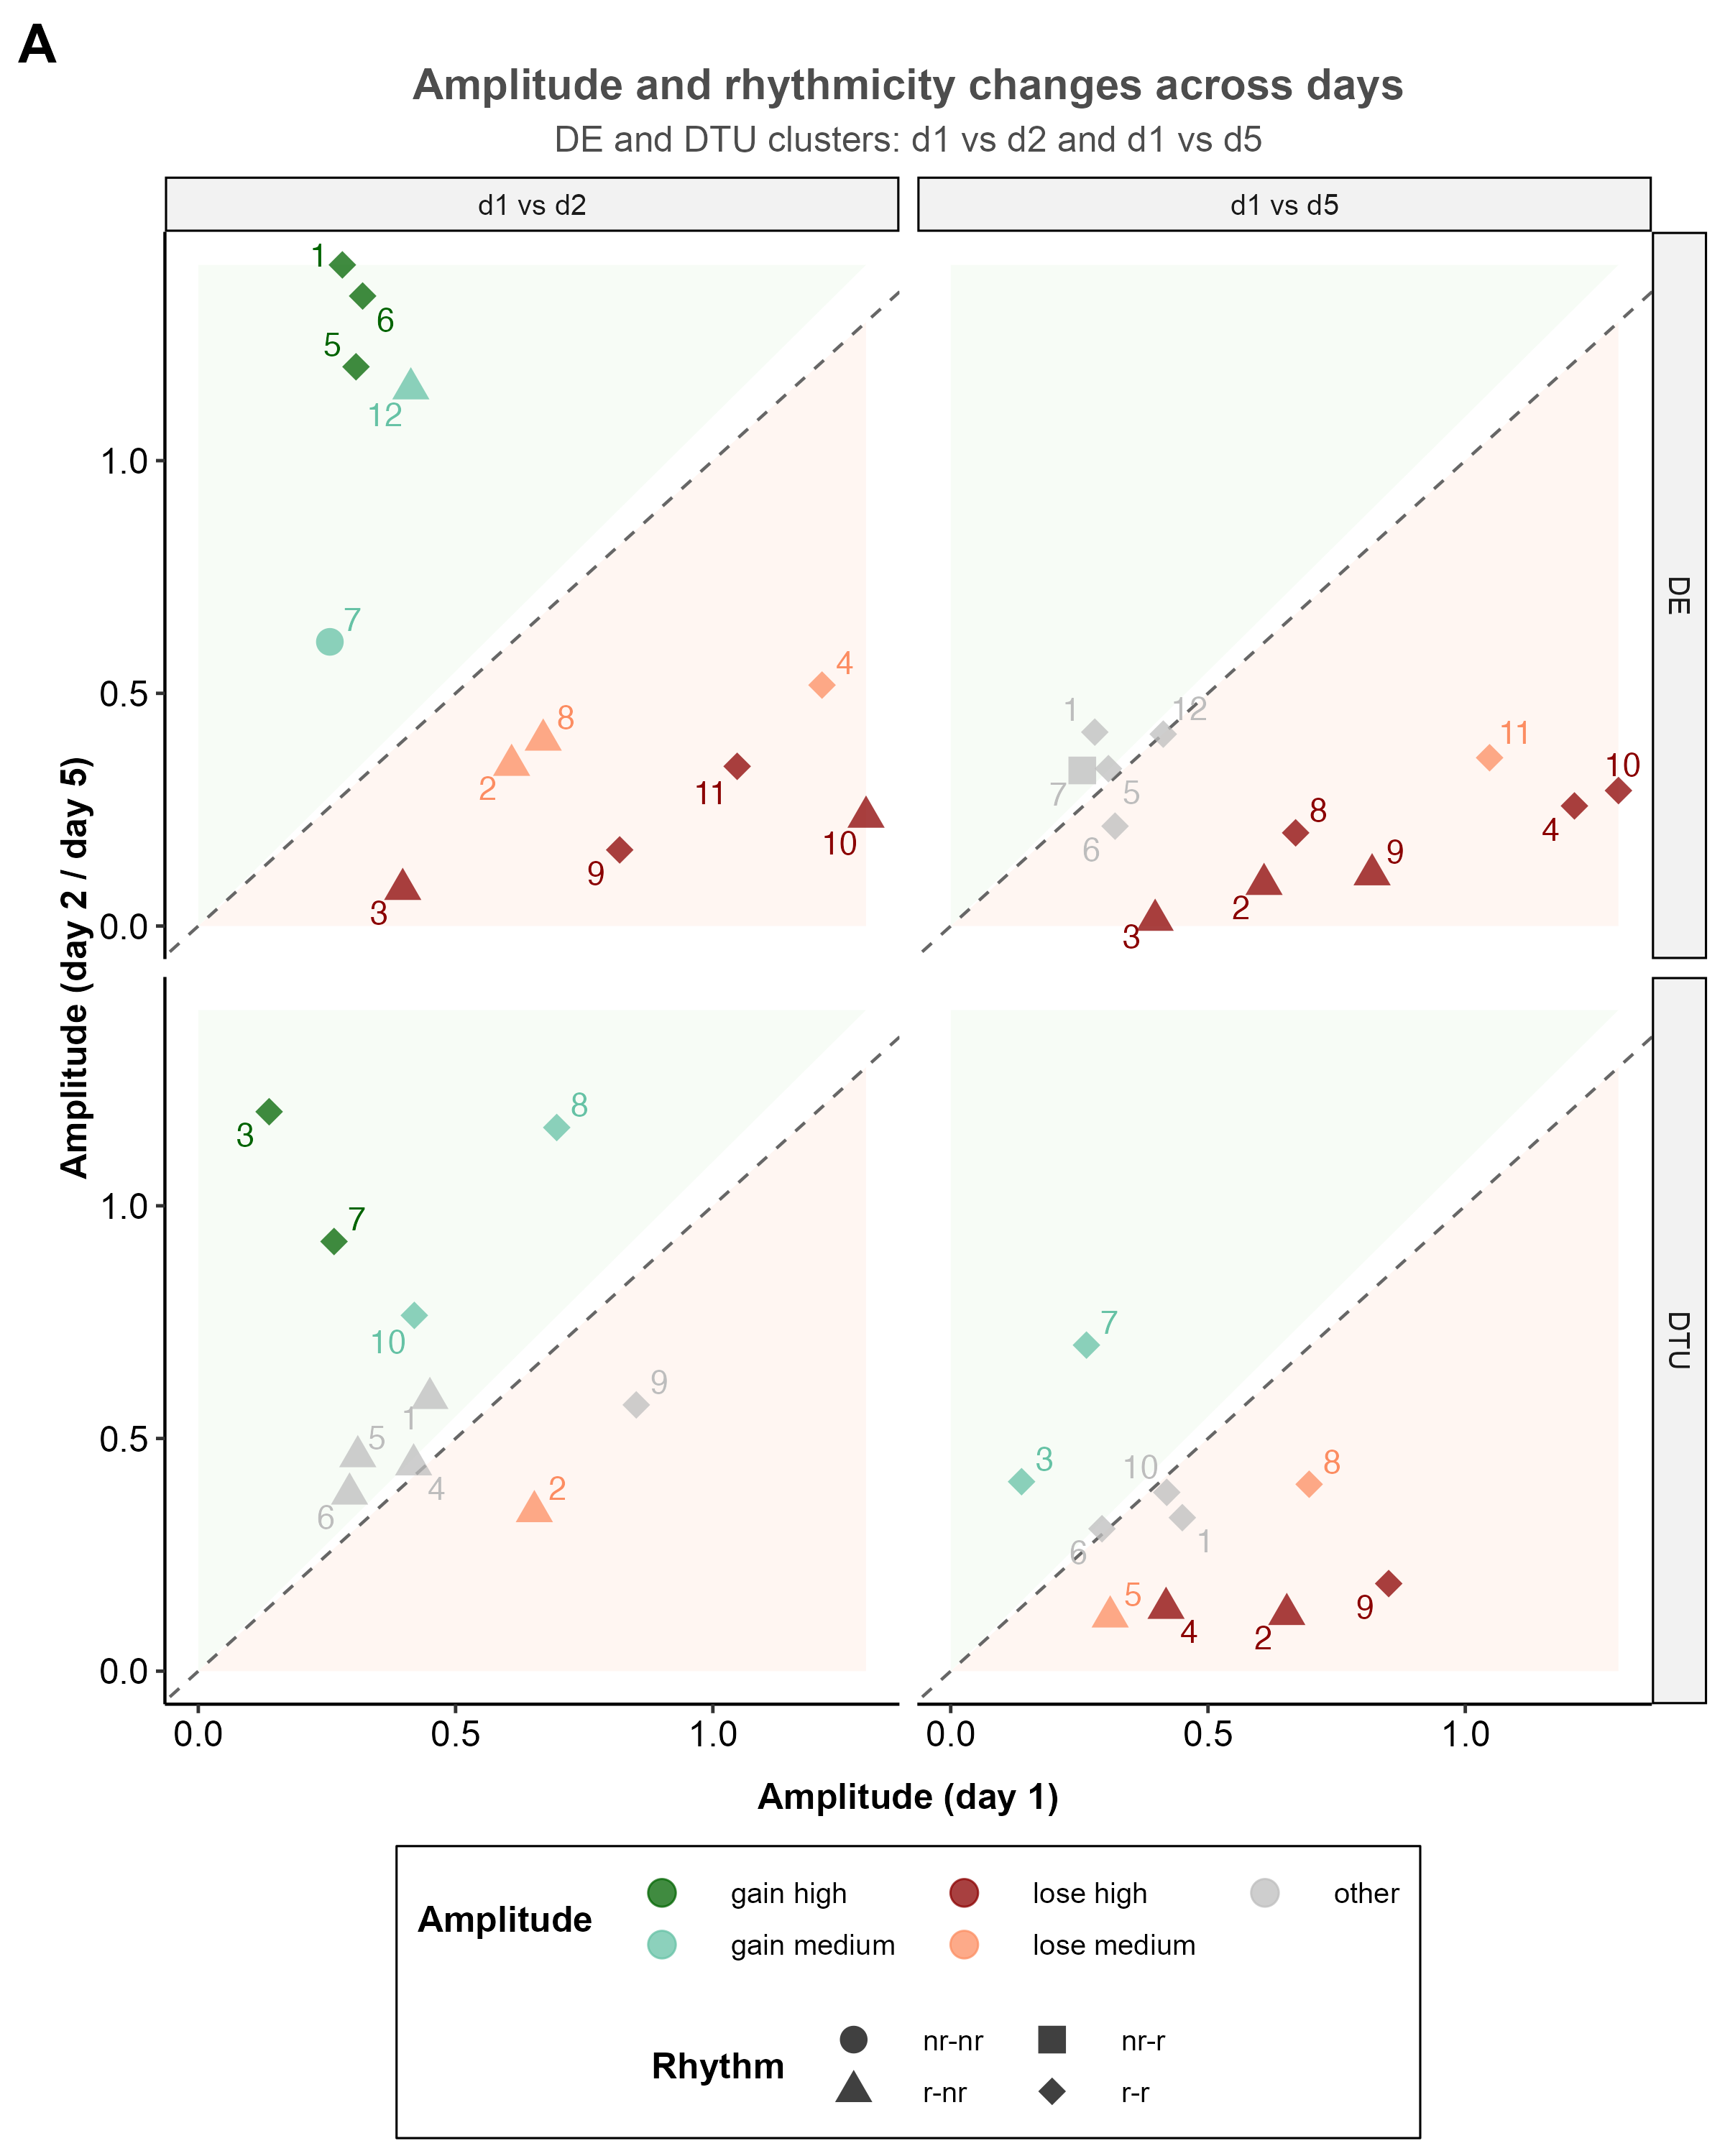{#fig-scatter-a }

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="100.0%" data-layout-align="left">
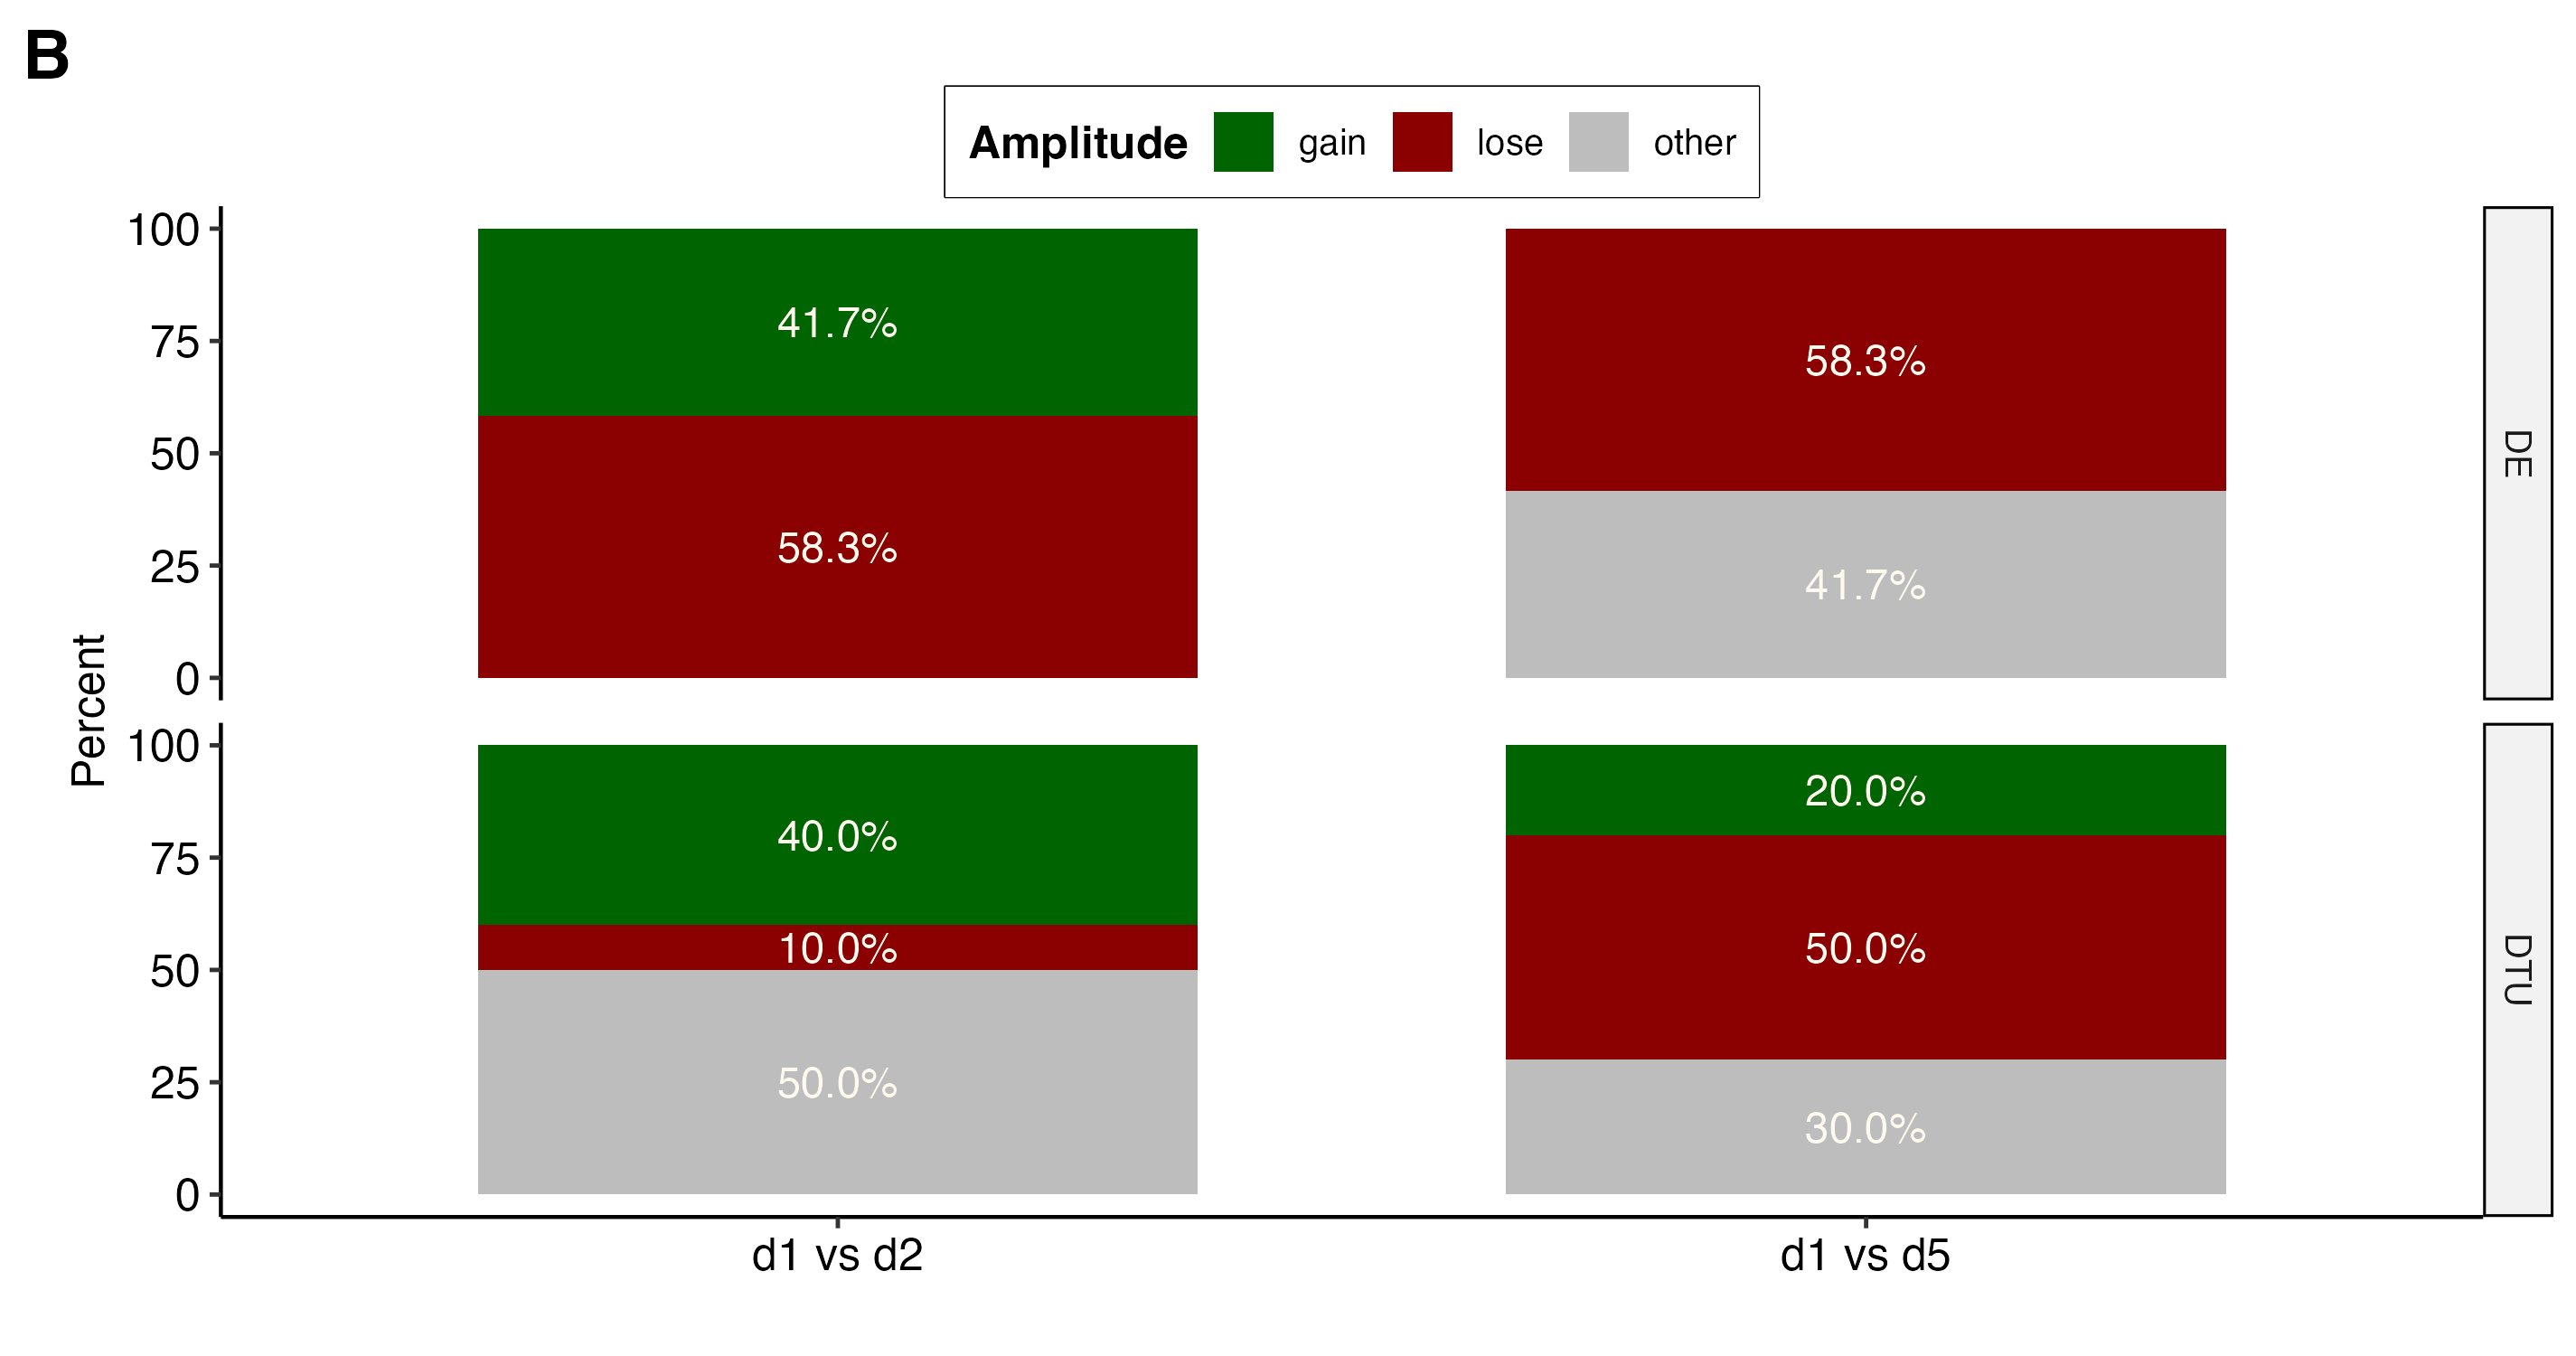
</div></td>
</tr>
</tbody>
</table>

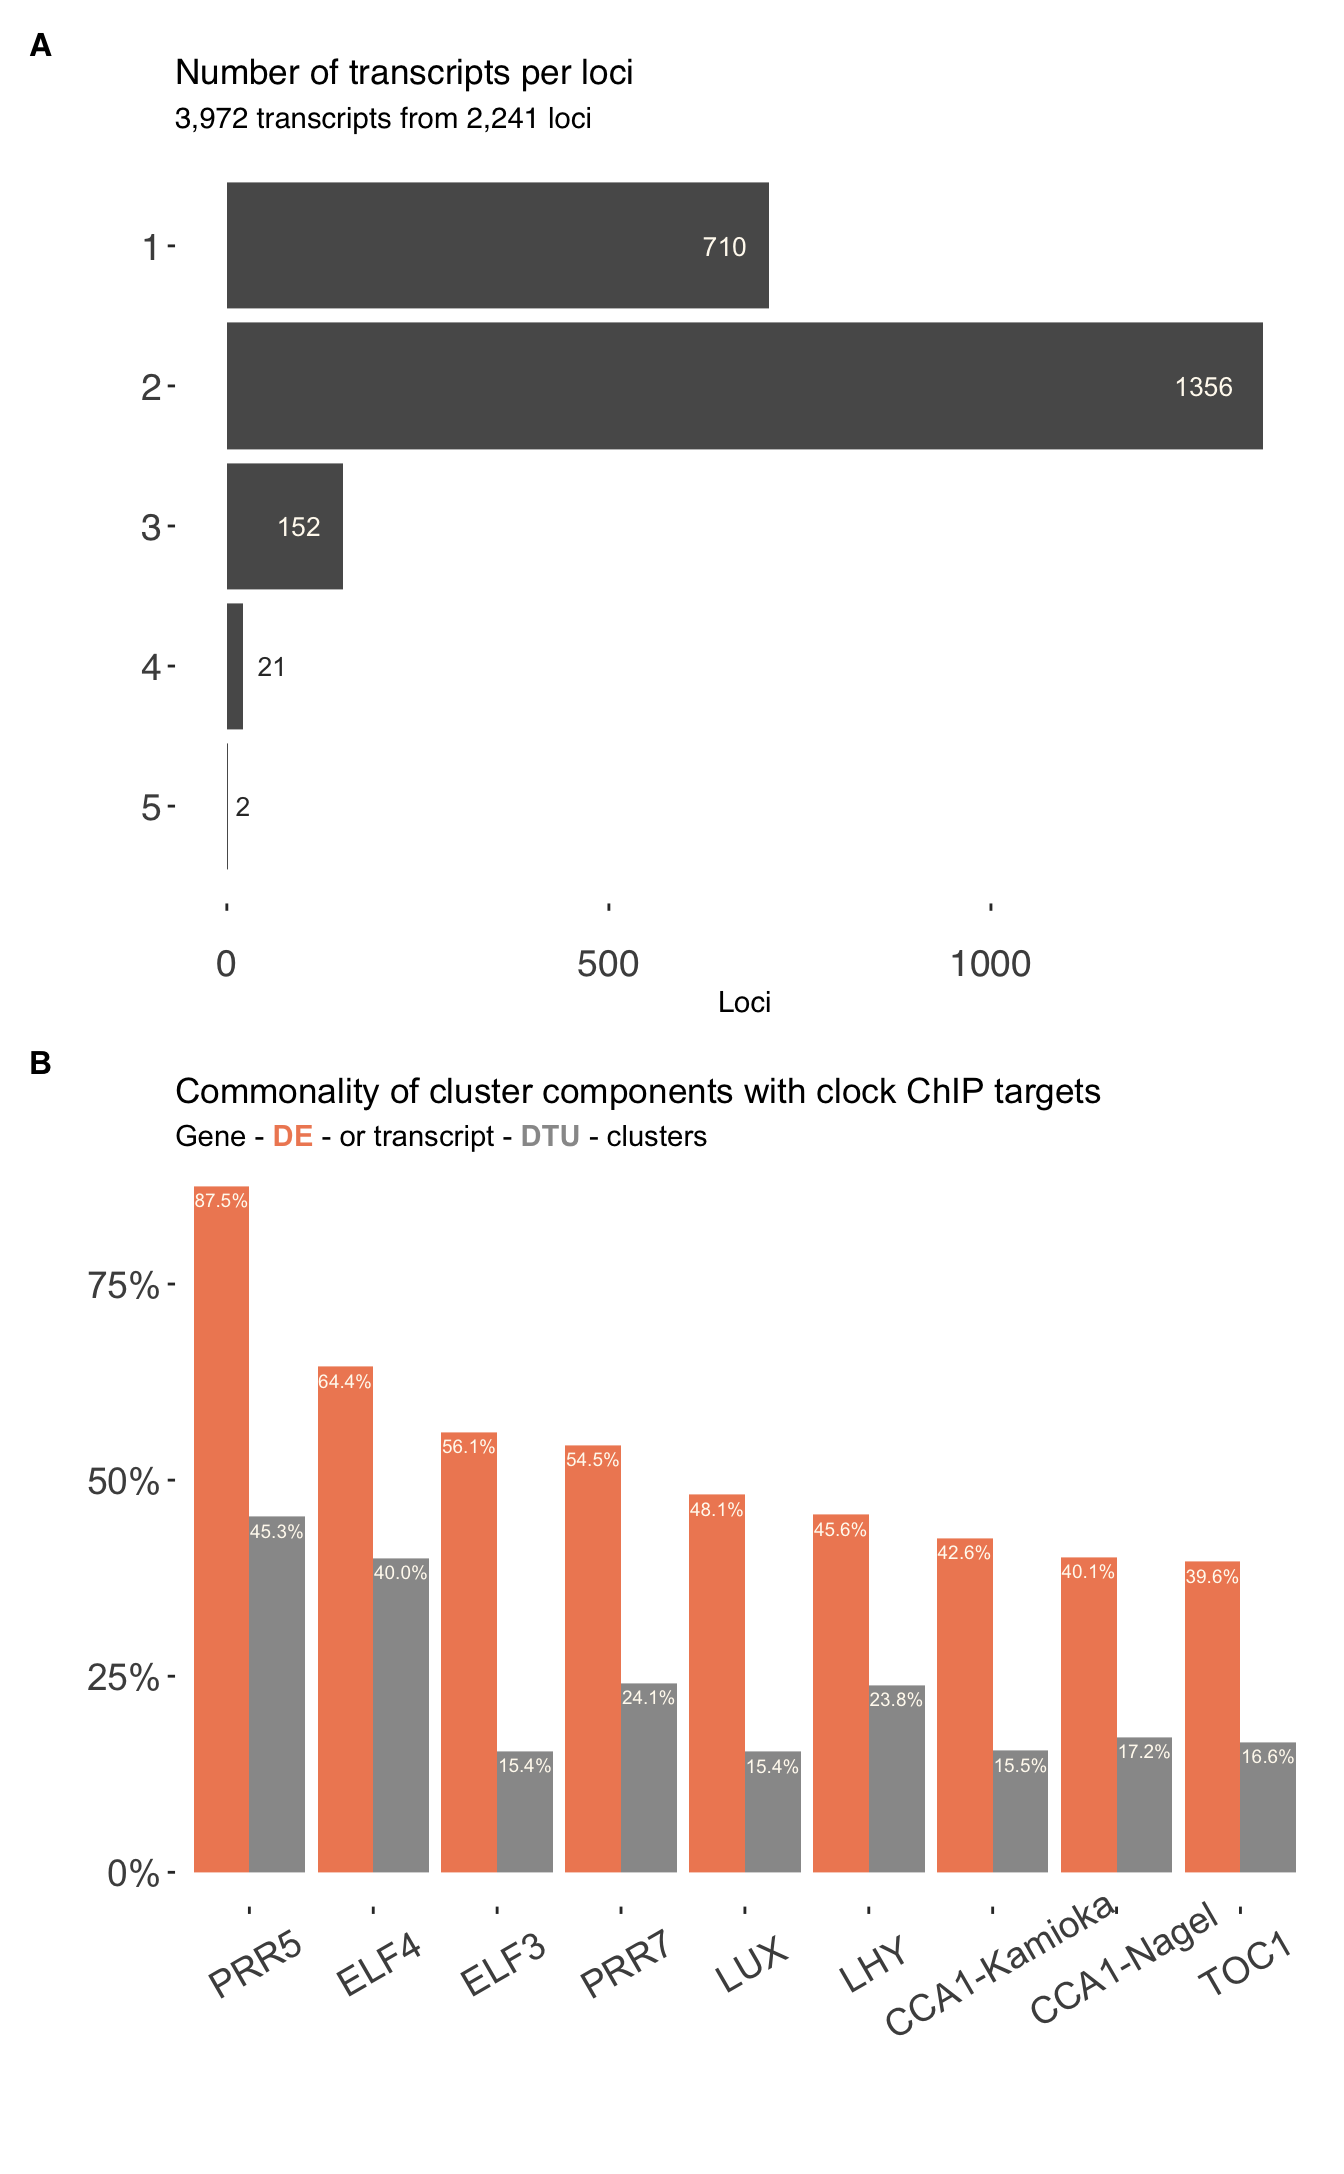

In [ ]:
calixto_S7B_summary_plot <- ggplot(calixto_S7B_summary, aes(x = n, y=transcripts)) +
  geom_bar(stat='identity', position='dodge') +
  geom_text(aes(label = transcripts), hjust = c(1.5, 1.5, 1.5, -0.5, -0.5),
            size = 3.5, colour = c('floralwhite', 
                                 'floralwhite', 
                                 'floralwhite', 
                                 'gray20', 
                                 'gray20')) +
  theme_tufte() +
  theme(text = element_text(family = 'Helvetica'),
        axis.text.x = element_text(size = 14, margin = margin(t = 5, unit = 'mm')),
        axis.text.y = element_text(size = 14),
        legend.position = "none",
        plot.tag = element_text(size = 20, face = 'bold')) +
  coord_flip() +
  scale_x_reverse() +
  labs(title = 'Number of transcripts per loci',
       subtitle = '3,972 transcripts from 2,241 loci',
       x = '',
       y = 'Loci')

plot_order <- 
  summarise_merge %>% 
  filter(type == "DE") %>% 
  arrange(desc(proportion)) %>% 
  mutate(labels = factor(clock))

summarise_merge_plot <- summarise_merge %>%
  mutate(labels = factor(clock, levels = plot_order$labels, ordered = TRUE)) %>% 
  ## add percentage label with `scales::percent()`
  mutate(perc = scales::percent(merge_total / CHIPs_total, accuracy = .1, trim = FALSE))

col_vec <- c(
  'DE' = '#ef8a62',
  'DTU' = '#999999'
)

ggtext_subtitle <- glue::glue(
  "Gene -
  **<span style='color:{col_vec[[1]]}'>{names(col_vec)[[1]]}</span>** - or transcript -
  **<span style='color:{col_vec[[2]]}'>{names(col_vec)[[2]]}</span>** - clusters"
)

# Bar plot
CHIP_merge_plot <- ggplot(summarise_merge_plot, aes(x = labels, y=proportion, fill=type), group = labels) +
  geom_bar(stat='identity', position='dodge') +
  geom_text(aes(label = perc), vjust = 1.5,
            position = position_dodge(.9), size = 2.5, colour = 'floralwhite') +
  theme_tufte() +
  theme(text = element_text(family = 'Arial'),
        axis.text.x = element_text(angle = 30, size = 14, margin = margin(t = 5, unit = 'mm')),
        axis.text.y = element_text(size = 14),
        legend.position = "none",
        plot.subtitle = element_textbox_simple()) +
  scale_fill_manual(values = col_vec) +
  scale_y_continuous(labels = scales::percent)+
  labs(title = 'Commonality of cluster components with clock ChIP targets',
       subtitle = ggtext_subtitle,
       x = '',
       y = '')

calixto_S7B_summary_plot / CHIP_merge_plot +
  plot_annotation(tag_levels = 'A') &
  theme(plot.tag = element_text(size = 12, face = 'bold')) &
  theme(plot.background = element_rect(fill = "white", colour = "white"))

![DE and DTU cluster amplitudes and rhythms across cooling](attachment:03_plots/p_panel_legend.png "DE and DTU cluster amplitudes and rhythms across cooling"){#fig-scatter_amp_rhythm fig-alt="Scatter plots of cluster amplitudes and rhythms for the DE and DTU clusters"}

blah @fig-scatter_amp_rhythm blah

![Summary of DE and DTU cluster amplitude and rhythm changes across cooling](attachment:03_plots/p_panel_summary_legend.png "Summary of the DE and DTU cluster amplitude and rhythm changes across cooling"){#fig-summary_amp_rhythm width="80%" fig-alt="Bar plots summarising cluster amplitude and rhythm changes with cooling for the DE and DTU clusters"}

![Combined summary of DE and DTU cluster amplitude and rhythm changes across cooling](attachment:03_plots/p_panel_scatter_summary_legend.png "Summary of the DE and DTU cluster amplitude and rhythm changes across cooling"){#fig-joined-summary_amp_rhythm width="80%" fig-alt="Bar plots summarising cluster amplitude and rhythm changes with cooling for the DE and DTU clusters"}

blah blag @fig-joined-summary_amp_rhythm A and @fig-joined-summary_amp_rhythm B blah blah

![Summary of DE and DTU amplitude dynamic changes across cooling](attachment:03_plots/p_panel_clock_summary_legend.png "Summary of the DE and DTU cluster amplitude dynamic changes across cooling"){#fig-amplitude-dynamic-changes fig-alt="Stacked bar plots summarising clock amplitude changes with cooling for the DE and DTU clusters"}

## Data & Methods

## Conclusion

## References
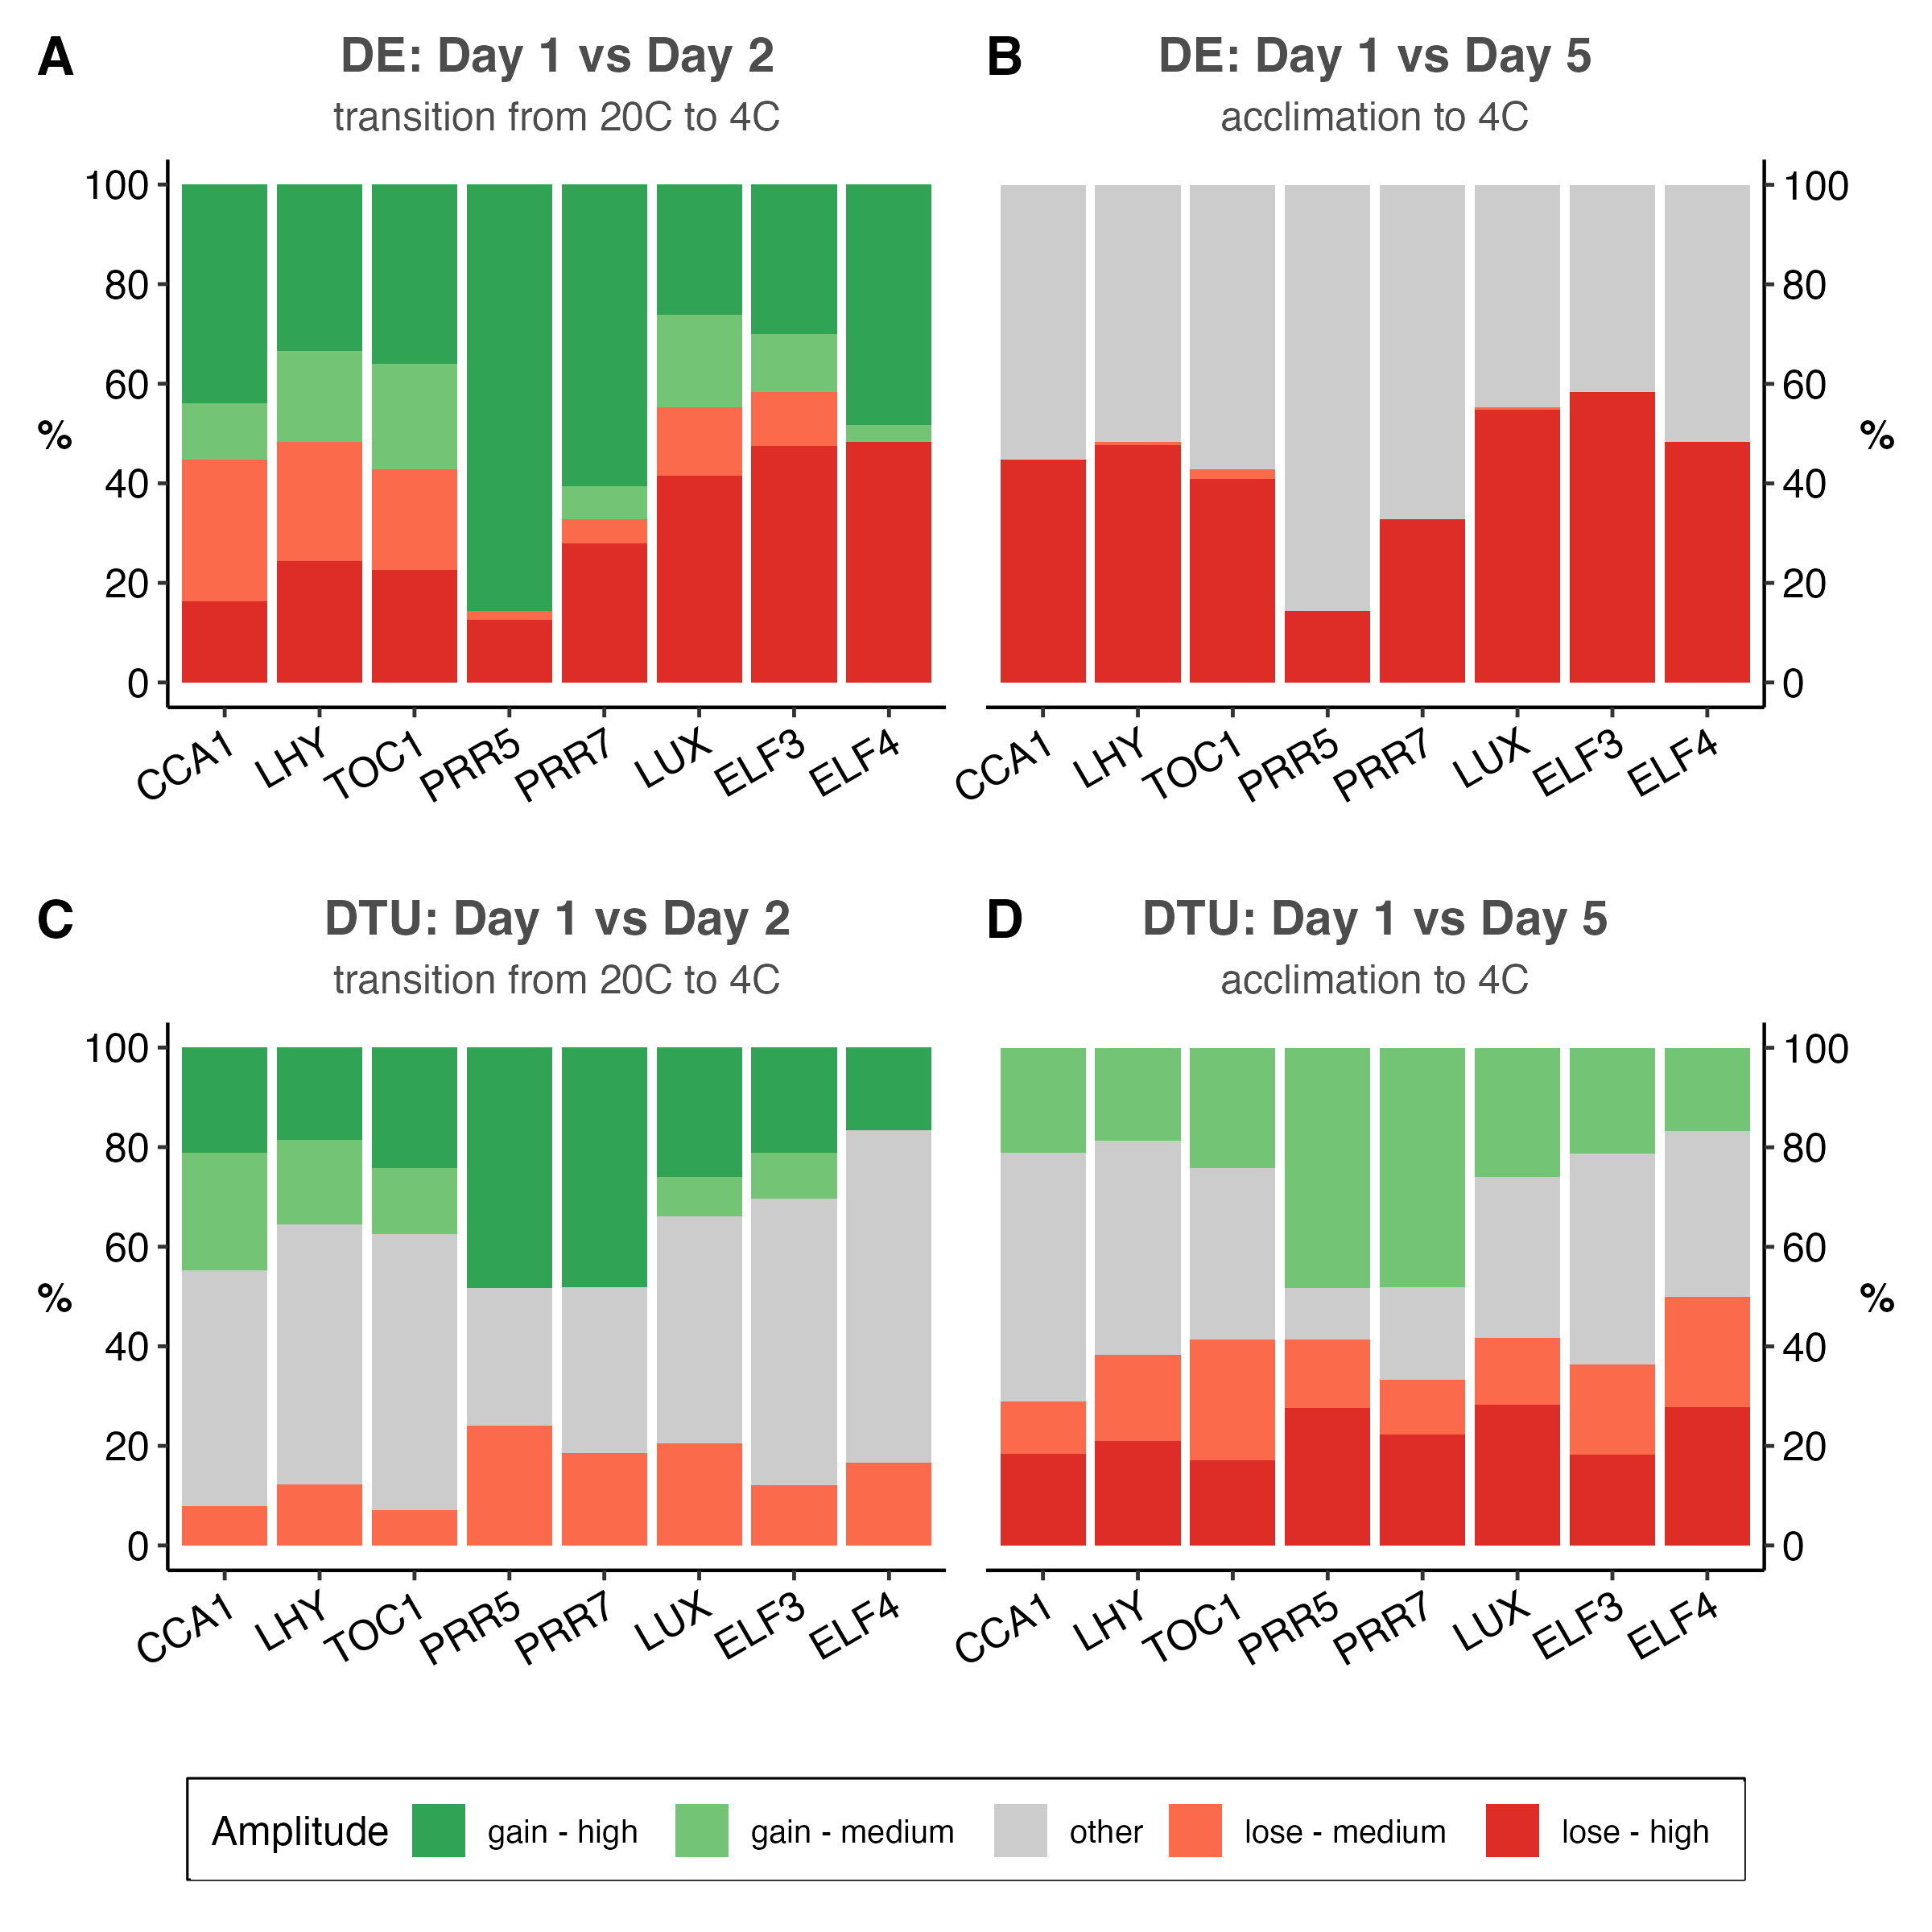
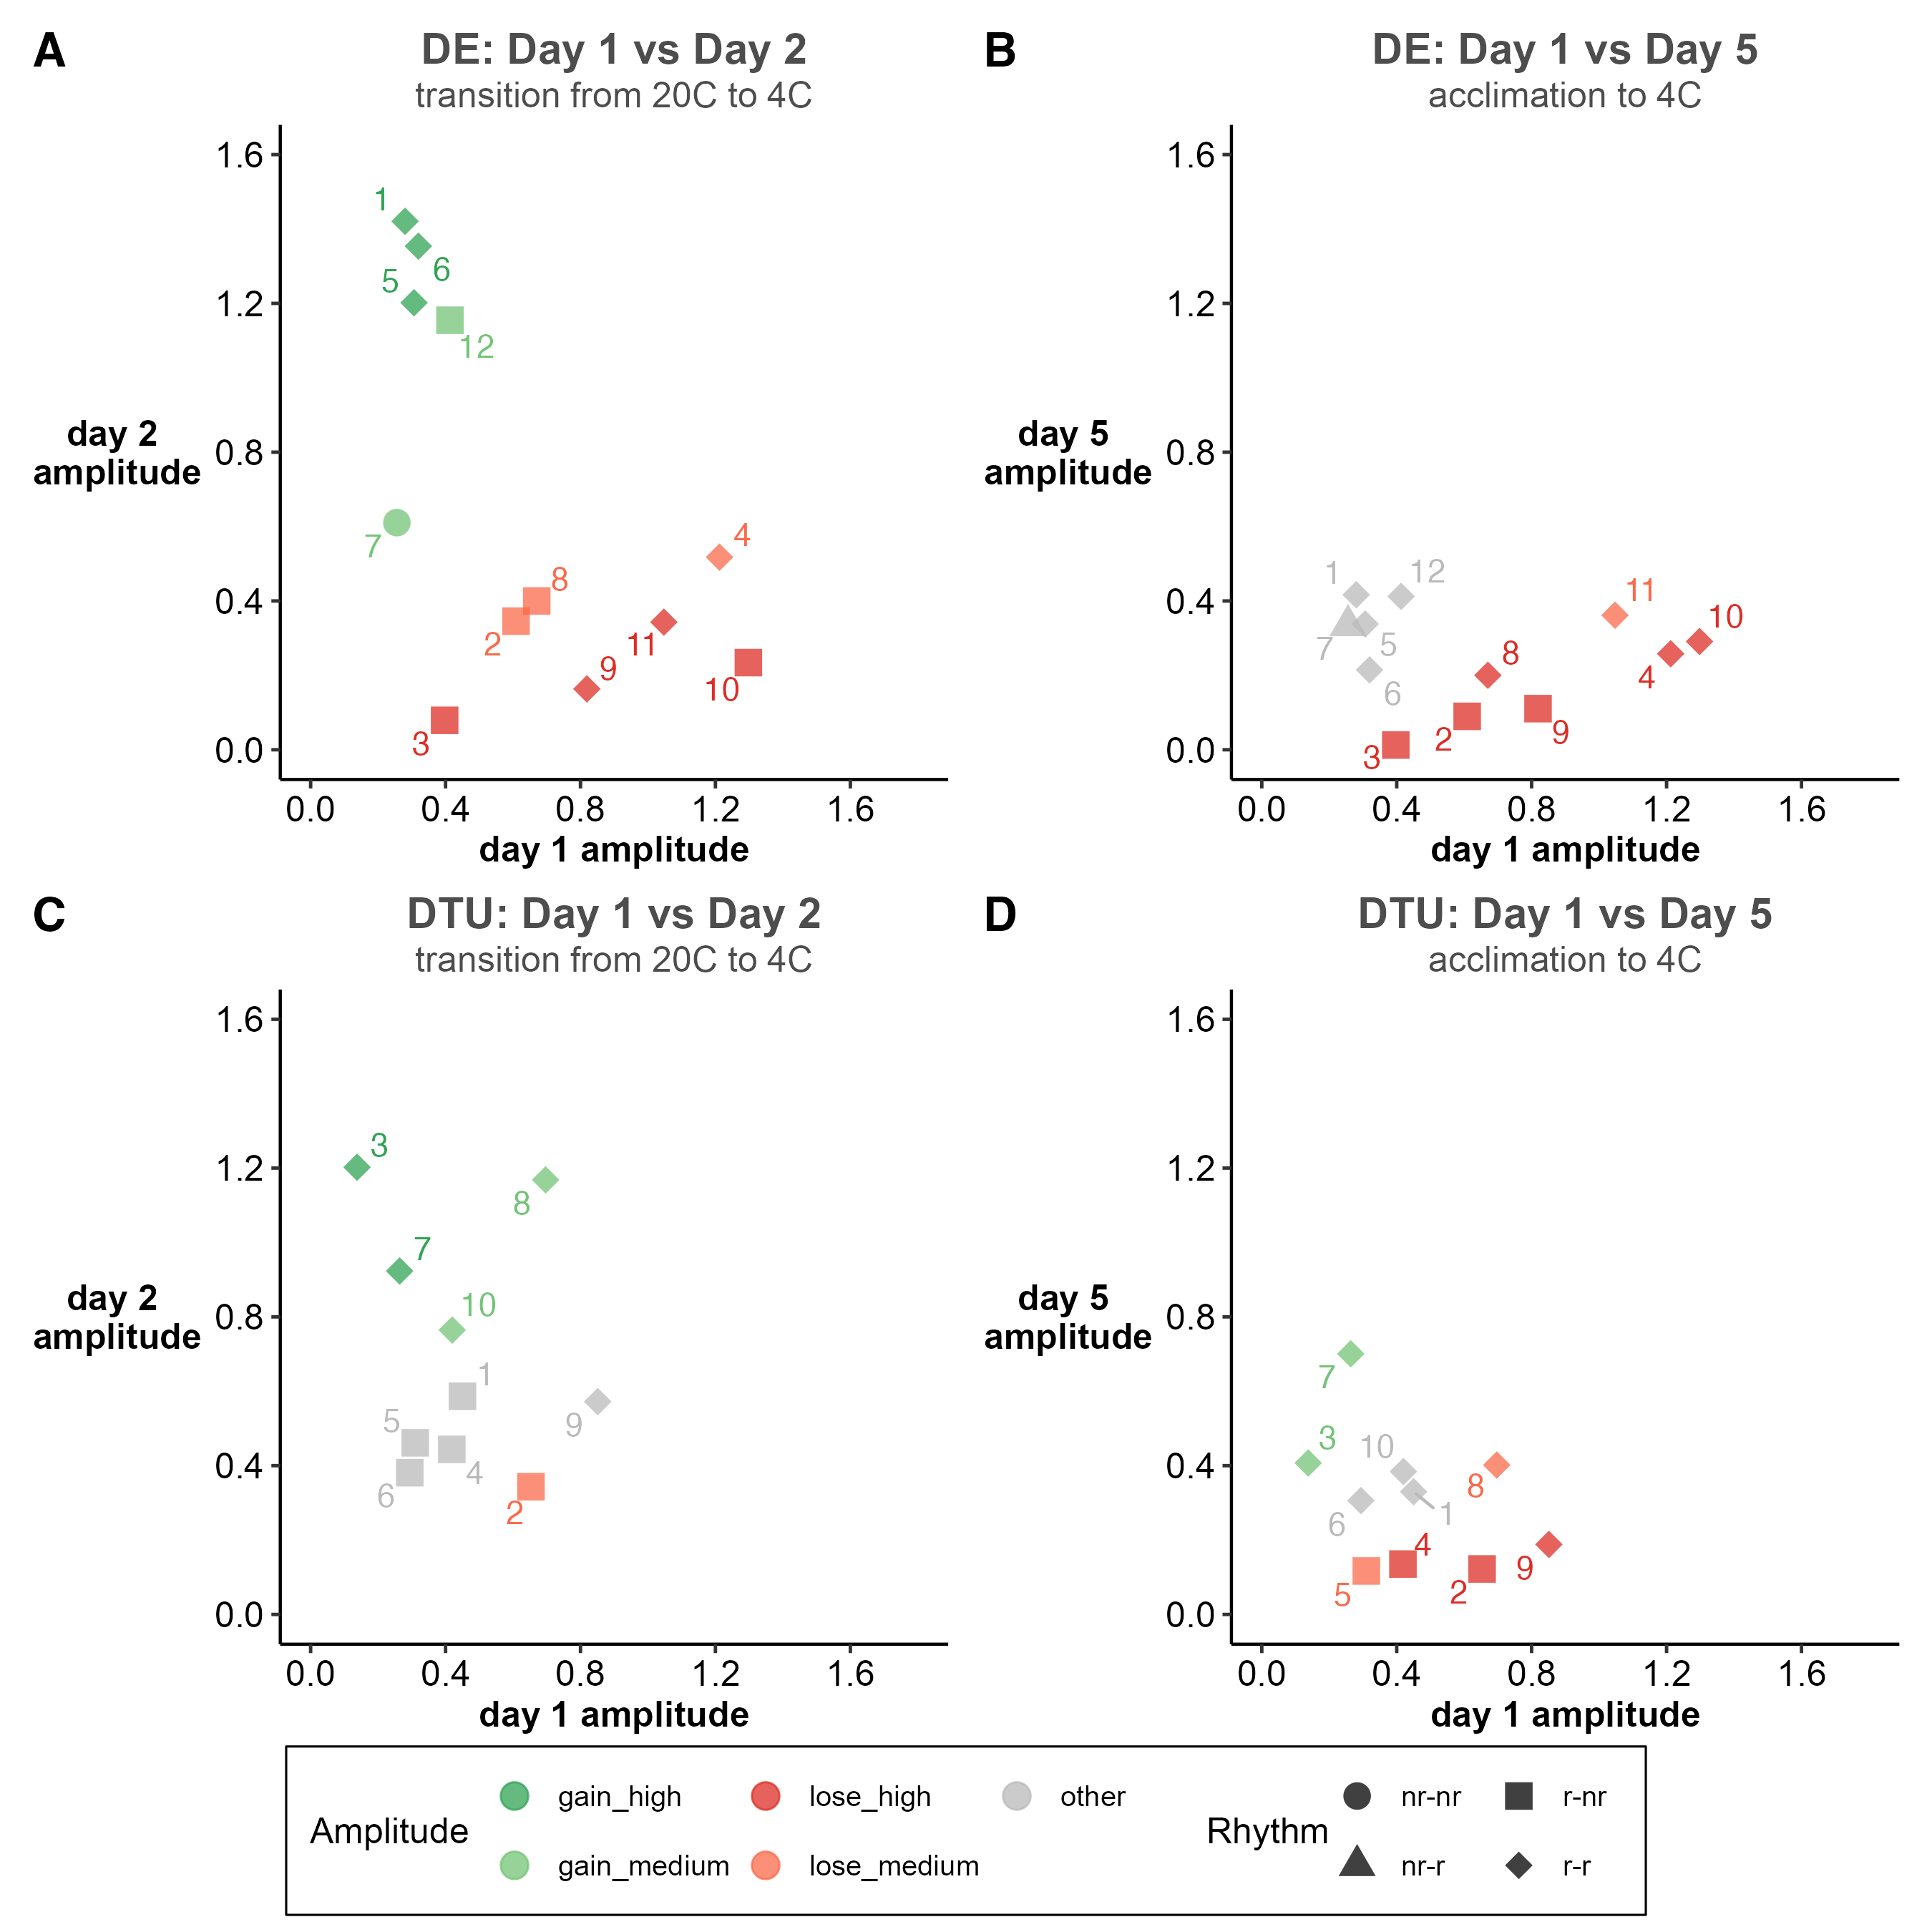
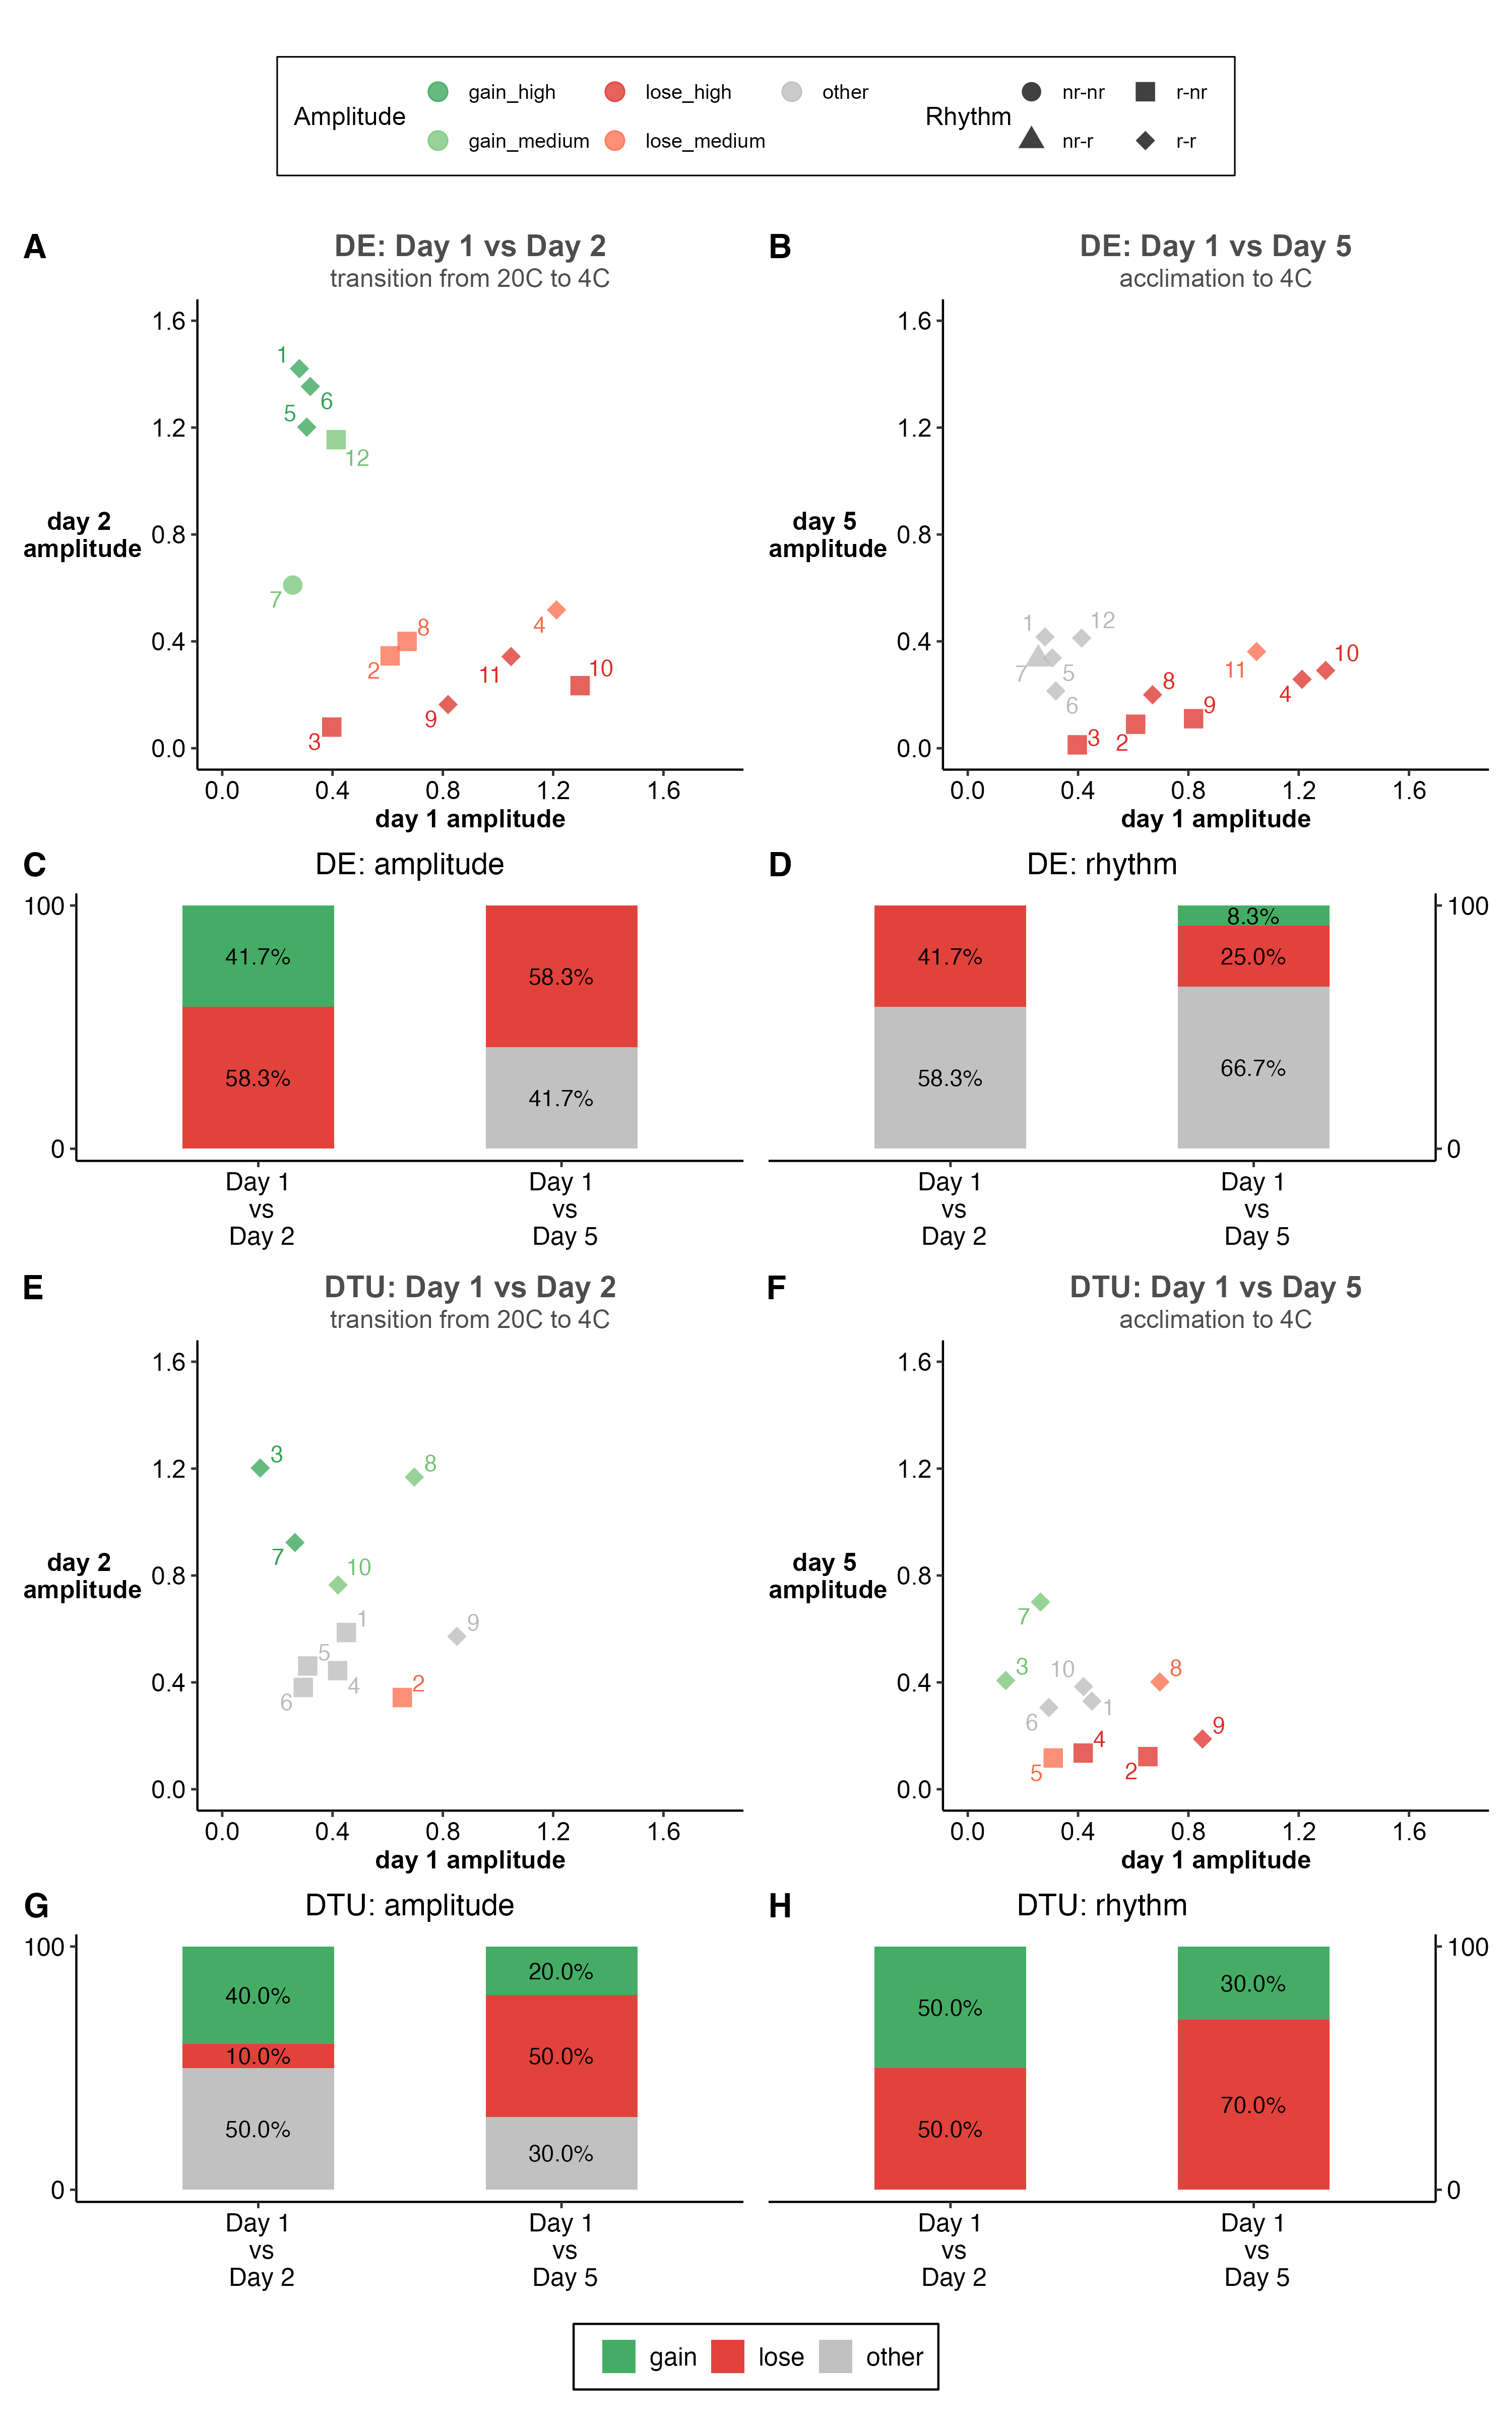
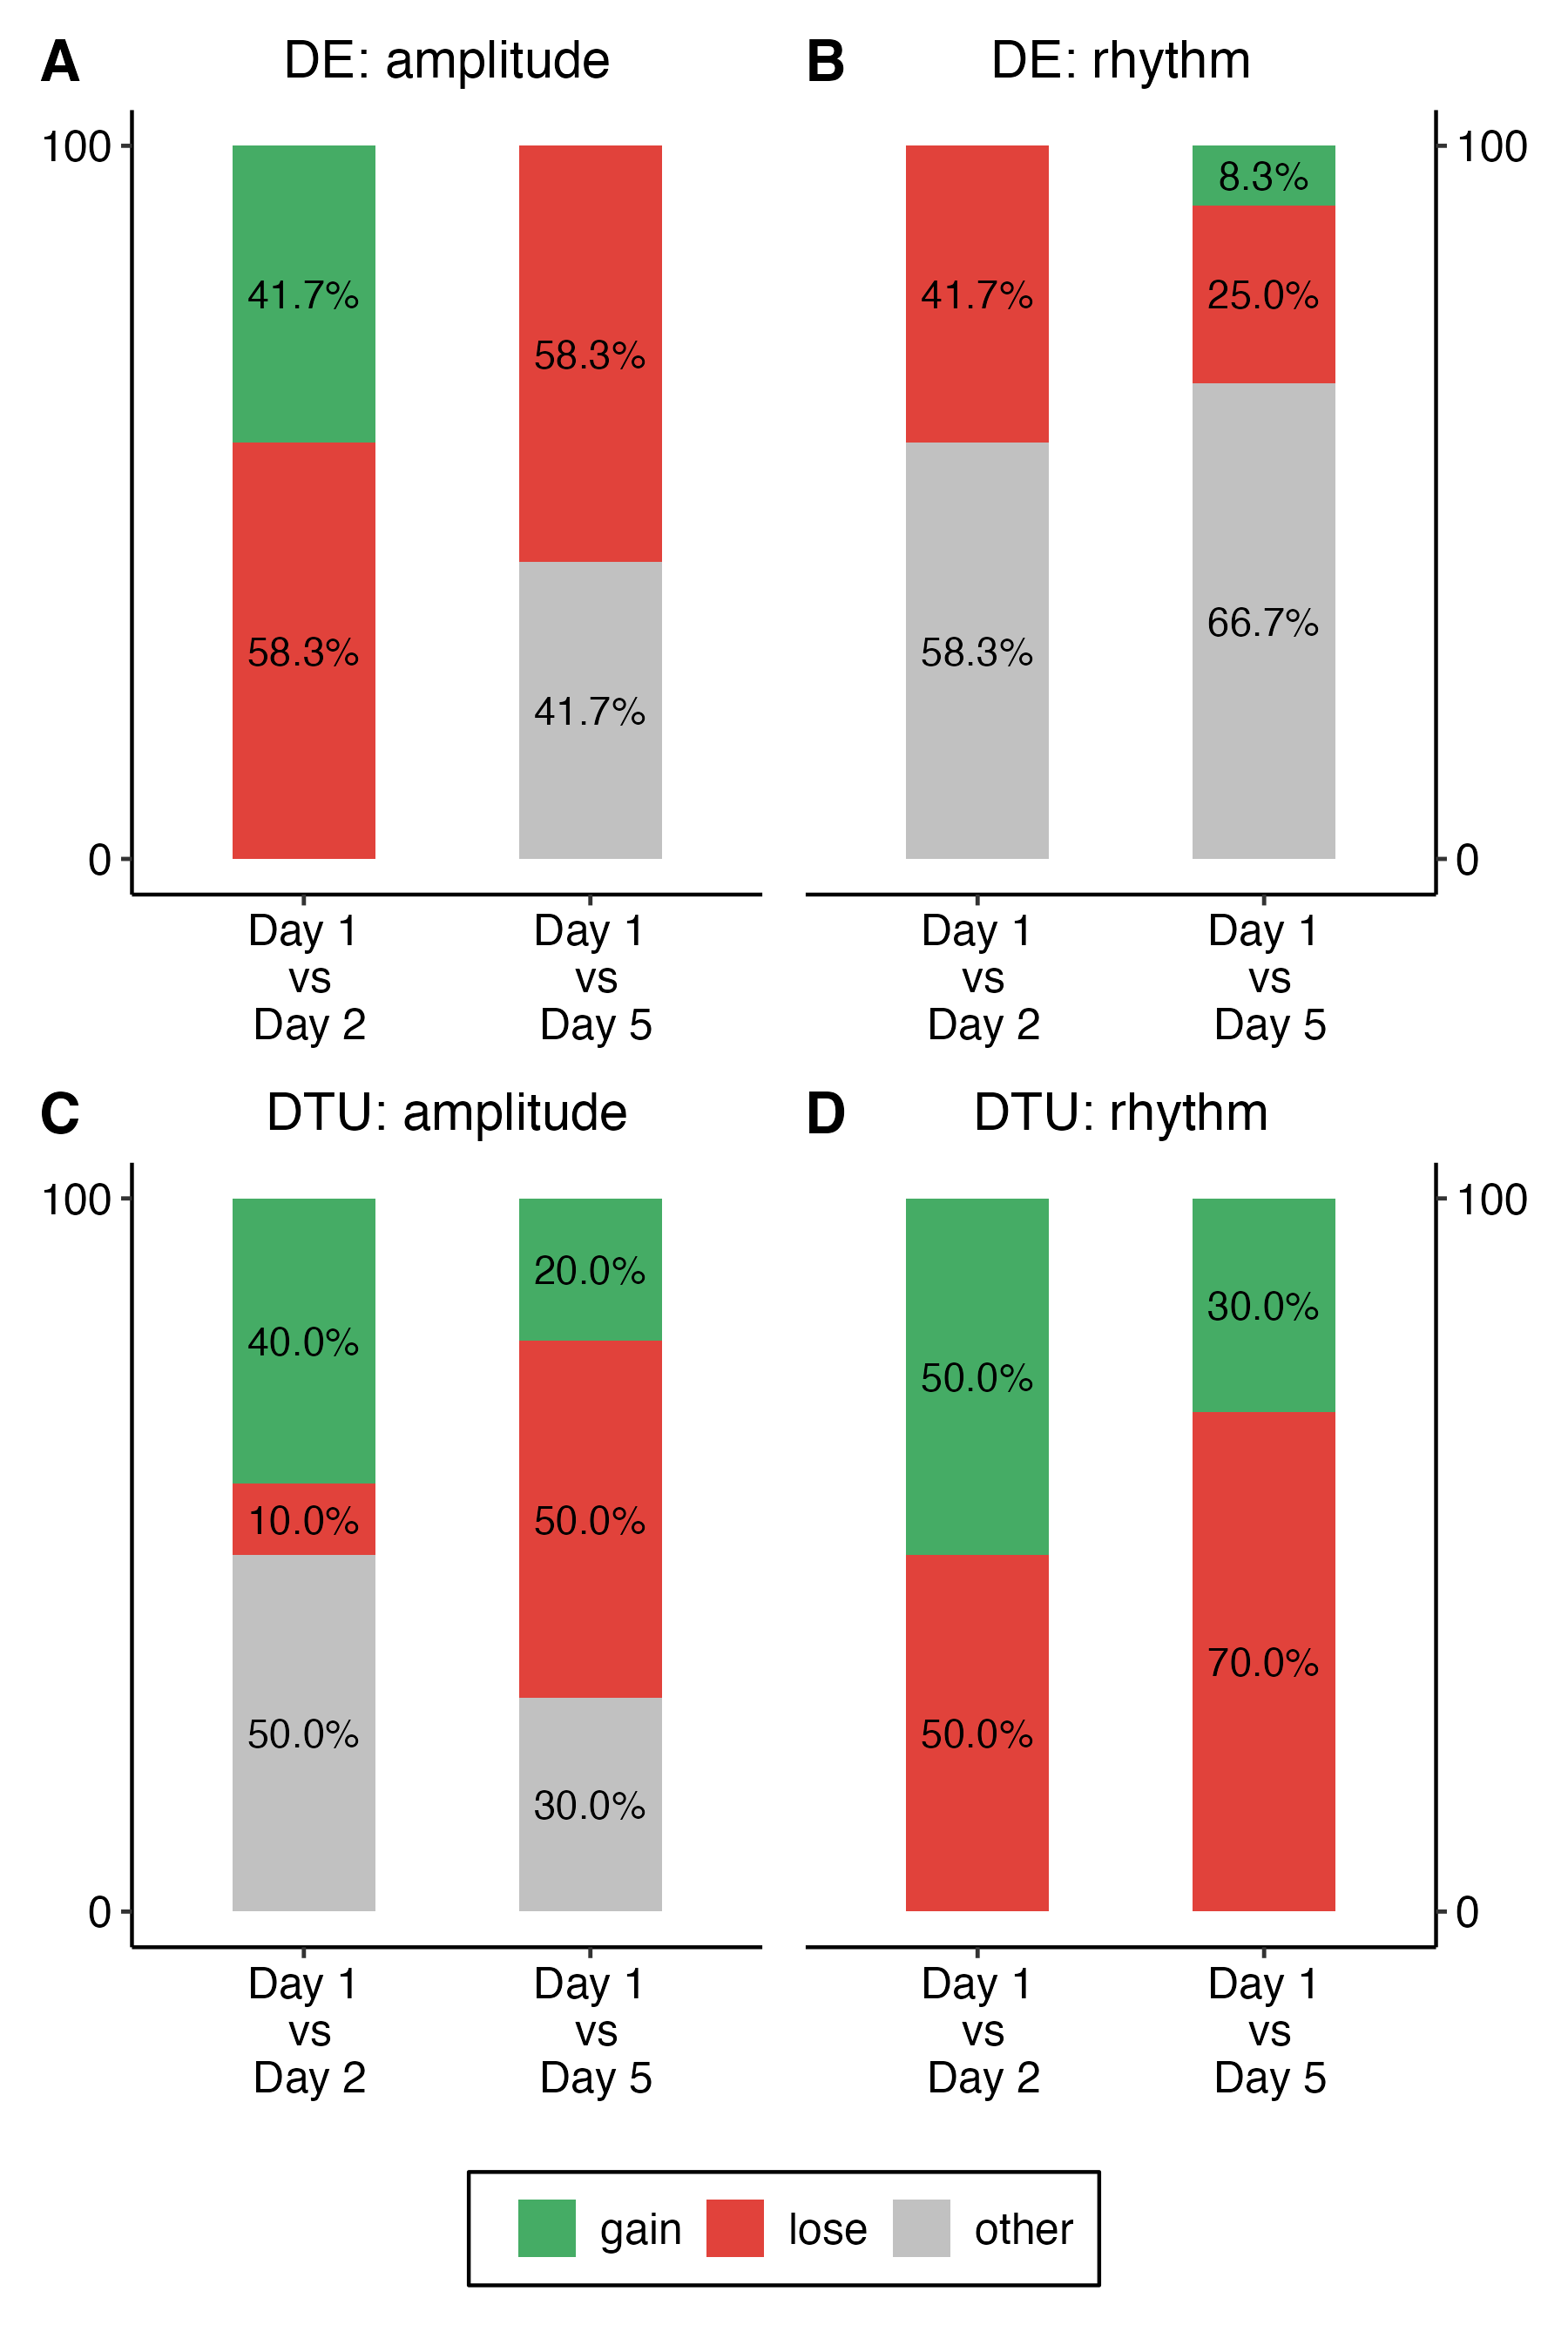